该部分为分析的第一阶段，对HFMD数据进行描述性分析。

In [1]:
#读取HFMD数据
import pandas as pd
HFMDData=pd.read_csv('/root/AnalysisData/HFMDProcess.csv',parse_dates=["Oneset_Data"])
HFMDData.info()

<class 'pandas.DataFrame'>
RangeIndex: 120138 entries, 0 to 120137
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Unnamed: 0     120138 non-null  int64         
 1   Oneset_Data    120138 non-null  datetime64[us]
 2   GenderToEln    120138 non-null  str           
 3   GenderEncoder  120138 non-null  int64         
 4   ComputerAge    120138 non-null  float64       
 5   Regional       120138 non-null  str           
 6   Population     120138 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(2), str(3)
memory usage: 6.4 MB


In [2]:
HFMDData.head(10)

,Unnamed: 0,Oneset_Data,GenderToEln,GenderEncoder,ComputerAge,Regional,Population
0,0,2018-01-16,Female,0,3.00,Huaxi District,Migrant Children
1,1,2018-04-02,Female,0,2.00,Huaxi District,Migrant Children
2,2,2018-04-02,Male,1,1.00,Guanshanhu District,Migrant Children
3,3,2018-04-11,Female,0,1.00,Other cities and states in the province,Migrant Children
4,4,2018-04-11,Female,0,4.00,Huaxi District,Nursery and Kindergarten Children
5,5,2018-04-11,Male,1,2.00,Guanshanhu District,Migrant Children
6,6,2018-04-13,Male,1,4.00,Wudang District,Migrant Children
7,7,2018-04-14,Female,0,0.67,Nanming District,Migrant Children
8,8,2018-04-14,Female,0,1.00,Huaxi District,Migrant Children
9,9,2018-04-21,Male,1,2.00,Yunyan District,Migrant Children


计算不同性别患者发病率(发病人口数/10万)
计算方法：发病率=发病人口数（月）/年平均人口数
总人口数:4751940(2018)、4817582（2019）、4869623（2020）、5851742（2021）、5931912（2022）

计算男性人群发病率
男性总人口数:2450197(2018)、2523782（2019）、2526811（2020）、2992247（2021）、3041876（2022）

In [3]:
#提取男性数据
MaleData=HFMDData.loc[HFMDData.loc[:,'GenderToEln']=='Male',:]

In [4]:
#计算发病率
def ComputerIR(data):
    #以月份为单位统计数据
    monthly_count=data.loc[:,"Oneset_Data"].dt.to_period('M').value_counts().sort_index()
    complete_date_range=pd.date_range(start="2018-01-01", end="2022-12-31", freq="MS")  # MS：每月第一天
    complete_month_index=complete_date_range.to_period('M')
    monthly_count_complete=monthly_count.reindex(complete_month_index, fill_value=0)
    monthly_count_complete_df=monthly_count_complete.reset_index()
    monthly_count_complete_df.columns =["year_month", "counts"]
    return monthly_count_complete_df
CounterMale=ComputerIR(data=MaleData)

In [5]:
#统计每年患病人口数
sum_2018_Male=CounterMale.iloc[:12,1].sum()
sum_2019_Male=CounterMale.iloc[12:24,1].sum()
sum_2020_Male=CounterMale.iloc[24:36,1].sum()
sum_2021_Male=CounterMale.iloc[36:48,1].sum()
sum_2022_Male=CounterMale.iloc[48:,1].sum()
print(f"年男性患者数:2018年{sum_2018_Male},2019年{sum_2019_Male},2020年{sum_2020_Male},2021年{sum_2021_Male},2022年{sum_2022_Male}")

年男性患者数:2018年20748,2019年21085,2020年9578,2021年8541,2022年8687


In [6]:
#计算男性2018年-2022年每个月HFMD发病率
IR_2018_Male=(CounterMale.iloc[:12,1]/2450197)*100000    #2018年
IR_2019_Male=(CounterMale.iloc[12:24,1]/2523782)*100000    #2019年
IR_2020_Male=(CounterMale.iloc[24:36,1]/2526811)*100000    #2020年
IR_2021_Male=(CounterMale.iloc[36:48,1]/2992247)*100000    #2021年
IR_2022_Male=(CounterMale.iloc[48:,1]/3041876)*100000    #2022年
print(f"男性年发病率:2018年{IR_2018_Male.sum()},2019年{IR_2019_Male.sum()},2020年{IR_2020_Male.sum()},2021年{IR_2021_Male.sum()},2022年{IR_2022_Male.sum()}")

男性年发病率:2018年846.7890541046293,2019年835.4525073877222,2020年379.0548640163431,2021年285.4376660750266,2022年285.5803458129128


计算女性人群发病率
男性总人口数:2301743(2018)、2293800（2019）、2342812（2020）、2859495（2021）、2890036（2022）

In [7]:
#提取女性数据
FemaleData=HFMDData.loc[HFMDData.loc[:,'GenderToEln']=='Female',:]

In [8]:
CounterFemale=ComputerIR(data=FemaleData)
#统计每年患病人口数
sum_2018_Female=CounterFemale.iloc[:12,1].sum()
sum_2019_Female=CounterFemale.iloc[12:24,1].sum()
sum_2020_Female=CounterFemale.iloc[24:36,1].sum()
sum_2021_Female=CounterFemale.iloc[36:48,1].sum()
sum_2022_Female=CounterFemale.iloc[48:,1].sum()
print(f"年女性患者数:2018年{sum_2018_Female},2019年{sum_2019_Female},2020年{sum_2020_Female},2021年{sum_2021_Female},2022年{sum_2022_Female}")

年女性患者数:2018年15709,2019年15405,2020年7354,2021年6642,2022年6389


In [9]:
#计算男性2018年-2022年每个月HFMD发病率
IR_2018_Female=(CounterFemale.iloc[:12,1]/2301743)*100000    #2018年
IR_2019_Female=(CounterFemale.iloc[12:24,1]/2293800)*100000    #2019年
IR_2020_Female=(CounterFemale.iloc[24:36,1]/2342812)*100000    #2020年
IR_2021_Female=(CounterFemale.iloc[36:48,1]/2859495)*100000    #2021年
IR_2022_Female=(CounterFemale.iloc[48:,1]/2890036)*100000    #2022年
print(f"女性年发病率:2018年{IR_2018_Female.sum()},2019年{IR_2019_Female.sum()},2020年{IR_2020_Female.sum()},2021年{IR_2021_Female.sum()},2022年{IR_2022_Female.sum()}")

女性年发病率:2018年682.4827967327369,2019年671.5929897985875,2020年313.89629214806826,2021年232.27877649724863,2022年221.06991054782705


In [10]:
data = {
    'Gender': ['Male', 'Female'],
    'Number of cases': [68639, 51499],  # 2018-2022年累计发病例数
    'Exposed population': [13534913, 12687886]  # 2018-2022年累计人口数
}
df = pd.DataFrame(data)
df['Unreported Cases'] = df['Exposed population'] - df['Number of cases']
df['IR (/100,000)'] = (df['Number of cases'] / df['Exposed population']) * 100000

In [11]:
df.round(4)

,Gender,Number of cases,Exposed population,Unreported Cases,"IR (/100,000)"
0,Male,68639,13534913,13466274,507.1255
1,Female,51499,12687886,12636387,405.8911


In [12]:
# 构建卡方检验所需的列联表（核心：发病例数 & 未发病例数）
# 列联表格式：行=性别，列=发病状态（发病/未发病）
contingency_table = df[['Number of cases', 'Exposed population']].values
print("=== 卡方检验列联表（频数）===")
contingency_df = pd.DataFrame(
    contingency_table,
    index=['Male', 'Female'],
    columns=['Number of cases', 'Exposed population']
)
contingency_df

=== 卡方检验列联表（频数）===


,Number of cases,Exposed population
Male,68639,13534913
Female,51499,12687886


In [13]:
expected_df = pd.DataFrame(
    contingency_df.round(2),
    index=['Male', 'Female'],
    columns=['Number of cases', 'Exposed population']
)
print(expected_df)

        Number of cases  Exposed population
Male              68639            13534913
Female            51499            12687886


In [14]:
from scipy.stats import chi2_contingency
chi2_stat, p_value, dof, expected_freq = chi2_contingency(contingency_table)
#输出卡方检验结果
print(f"卡方统计量（χ²）：{chi2_stat:.4f}")
print(f"p值：{p_value:.8f}")
print(f"自由度（df）：{dof}")
print(f"检验水准（α）：0.05")

卡方统计量（χ²）：1458.0894
p值：0.00000000
自由度（df）：1
检验水准（α）：0.05


In [15]:
#合并发病率数据
from pandas import DataFrame
IRGender=DataFrame()
IRGender['Oneset_Data']=pd.date_range(start="2018-01-01", end="2022-12-31", freq="MS")
IRGender['IR of male']=pd.concat([IR_2018_Male,IR_2019_Male,IR_2020_Male,IR_2021_Male,IR_2022_Male],axis=0)
IRGender['IR of female']=pd.concat([IR_2018_Female,IR_2019_Female,IR_2020_Female,IR_2021_Female,IR_2022_Female],axis=0)

In [16]:
#输出男性和女性发病率数据
IRGender.to_csv('/root/ToResult/Stage1DescriptiveAnalysis/IRGender.csv',encoding='utf-8')

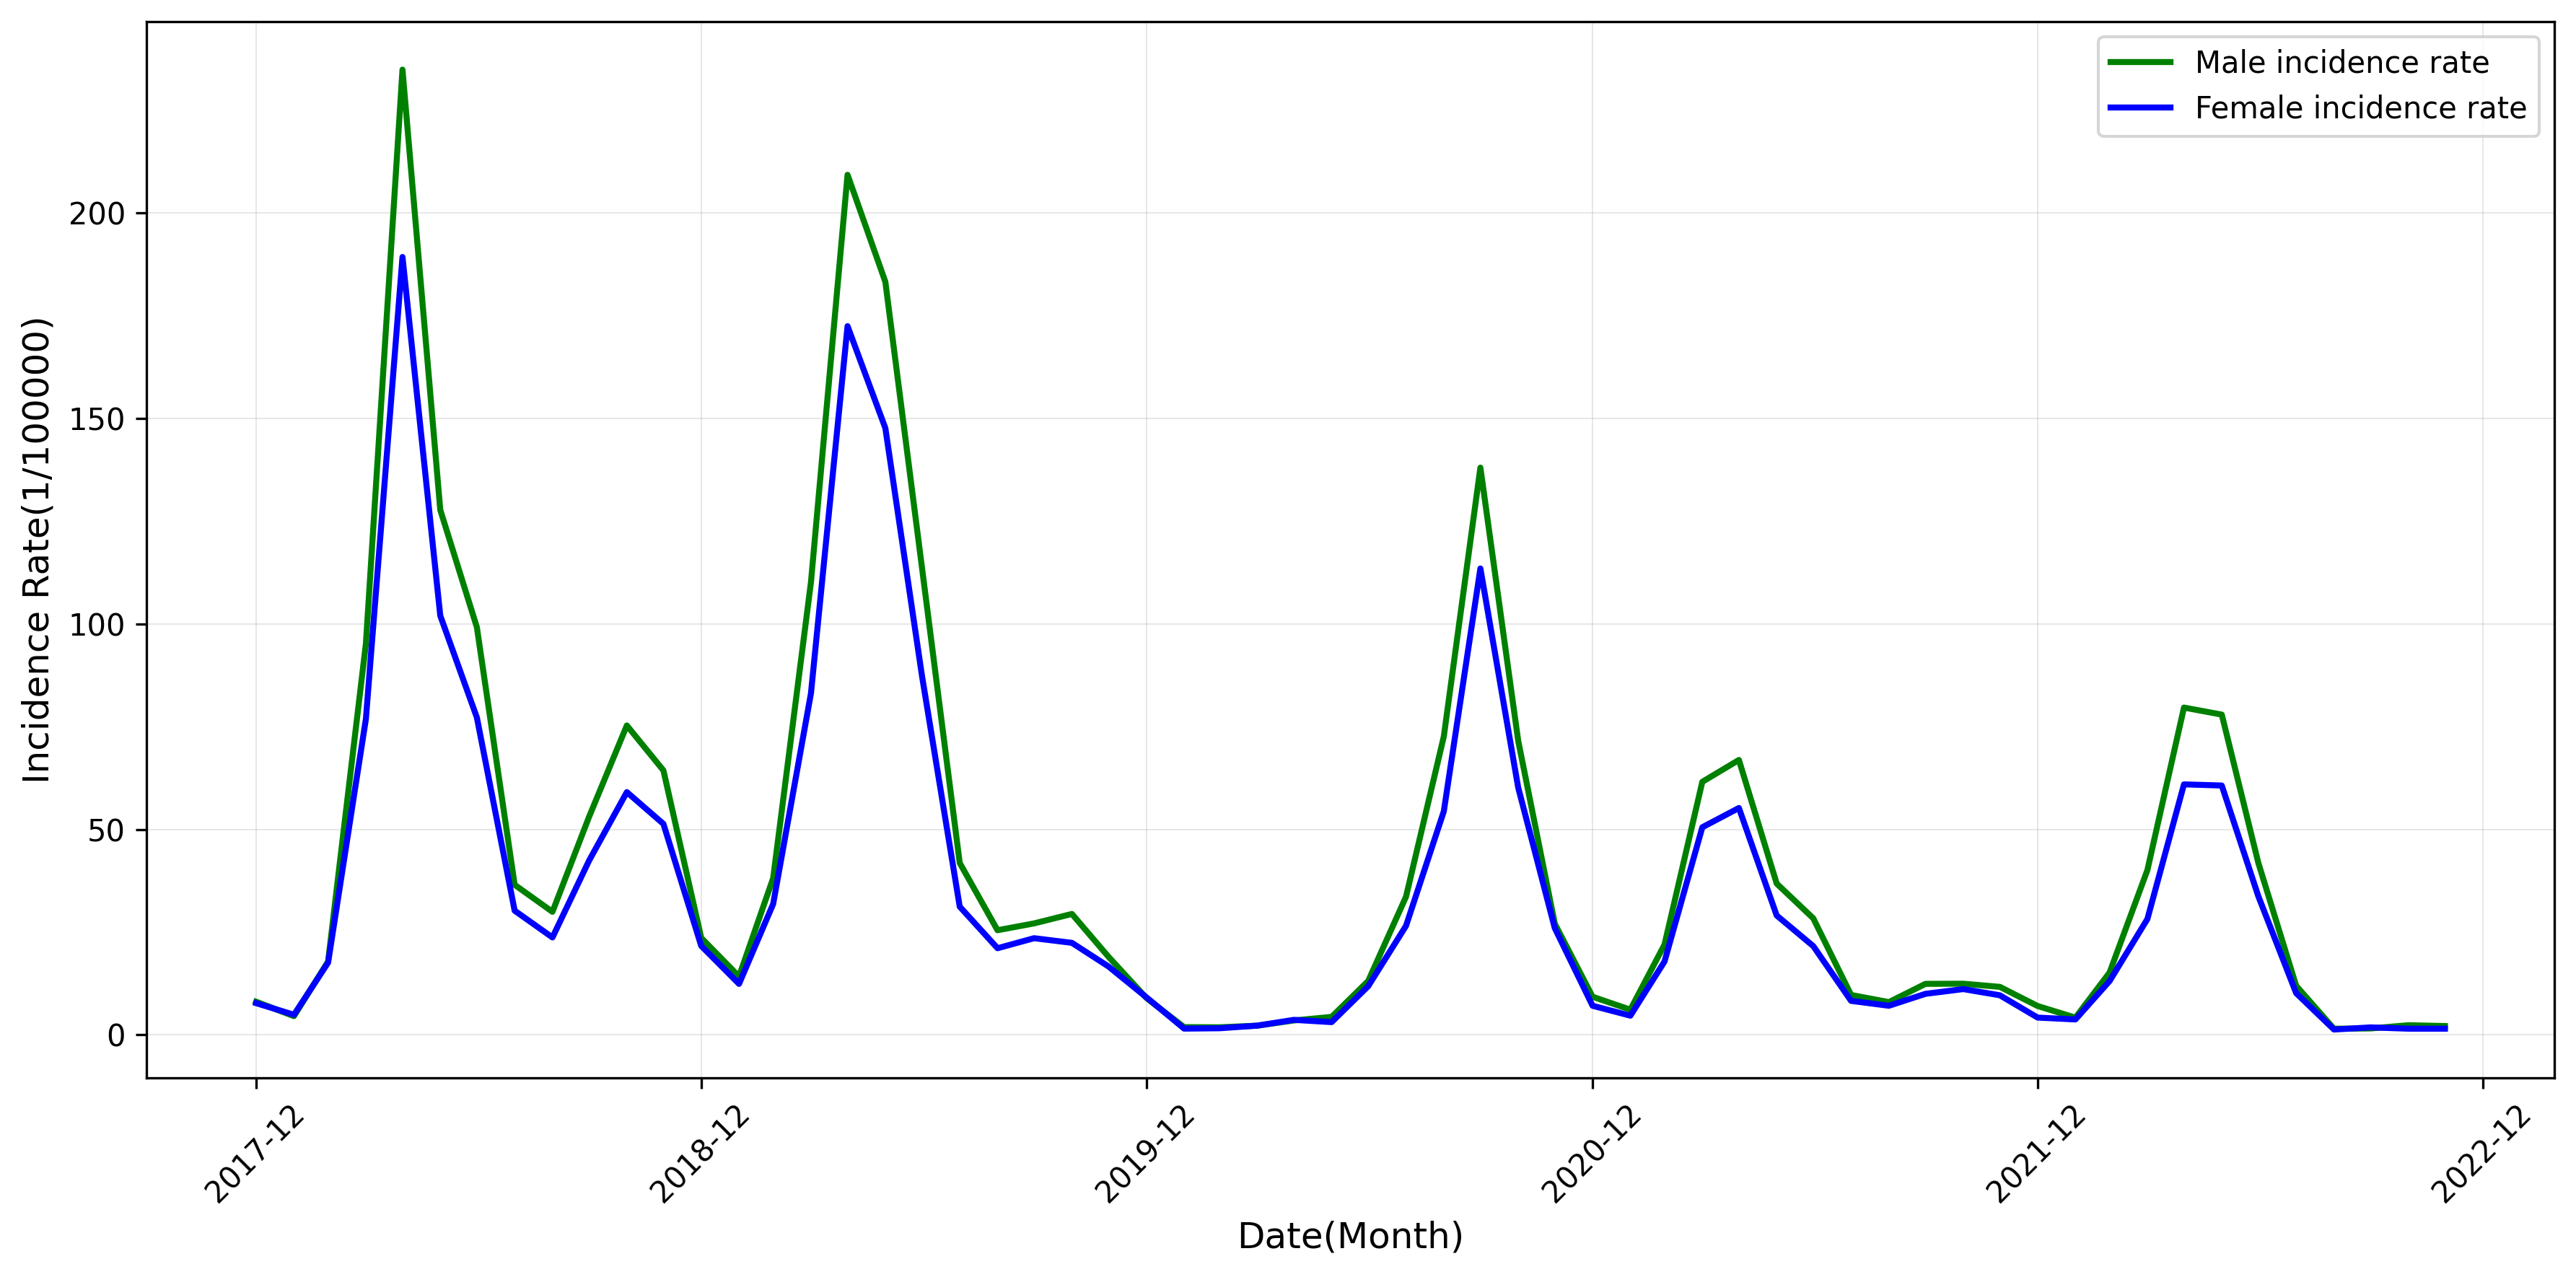

In [18]:
#绘制发病率数据曲线图
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.dates import DateFormatter, AutoDateLocator
fig,ax=plt.subplots(figsize=(12, 6),dpi=300)
ax.plot(IRGender["Oneset_Data"],IRGender["IR of male"], label="Male incidence rate",linewidth=2,markersize=4,color="green",alpha=1)
ax.plot(IRGender["Oneset_Data"],IRGender["IR of female"], label="Female incidence rate",linewidth=2,markersize=4,color="blue",alpha=1)
date_locator = AutoDateLocator()
date_formatter = DateFormatter("%Y-%m")
ax.xaxis.set_major_locator(date_locator)
ax.xaxis.set_major_formatter(date_formatter)
plt.xticks(rotation=45)
ax.set_title("", fontsize=14, pad=20)
ax.set_xlabel("Date(Month)", fontsize=12)
ax.set_ylabel("Incidence Rate(1/100000)", fontsize=12)
ax.legend(loc="best", fontsize=10)
ax.grid(True, alpha=0.3, linestyle="-", linewidth=0.5)
plt.tight_layout()
plt.show()

In [19]:
#计算男性和女性HFMD数据发病率描述性统计学指标
IRGender.loc[:,['IR of male','IR of female']].describe()

,IR of male,IR of female
count,60.000000,60.000000
mean,43.871907,35.355346
std,51.868919,41.561092
min,1.512225,1.314863
25%,8.787669,7.574741
50%,26.273665,21.639655
75%,64.998189,52.119736
max,234.879073,189.291333


/tmp/ipykernel_968/2270494467.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp =ax.boxplot(box_data, labels=labels, patch_artist=True, widths=0.6)


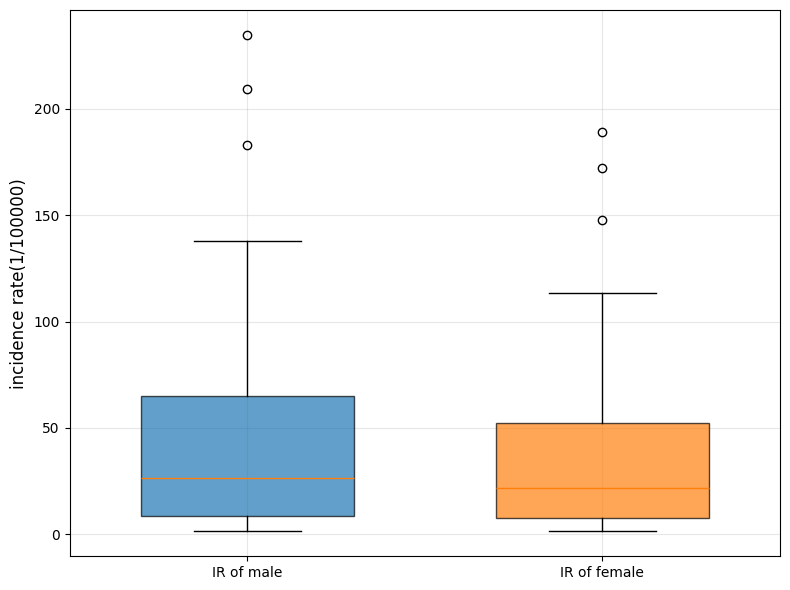

In [20]:
#绘制箱型图
import seaborn as sns
fig, ax = plt.subplots(figsize=(8, 6))
box_data =[IRGender['IR of male'],IRGender['IR of female']]
labels =["IR of male", "IR of female"]
bp =ax.boxplot(box_data, labels=labels, patch_artist=True, widths=0.6)
colors = ["#1f77b4", "#ff7f0e"]
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_title("", fontsize=14)
ax.set_ylabel("incidence rate(1/100000)", fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

在不同年份，分析不同职业和地域的HFMD发病率差异；分为单独分析不同职业和以及差异差异以及汇总分析职业和地域差异。

In [23]:
import seaborn as sns
#不同地域和不同职业人群发病差异
def Describe(RegionalIRDF,RegY,PopulationIRDF,PopY):
    #地域
    print(f'不同地区HFMD发病率描述性指标:{RegionalIRDF.describe()}')
    fig,ax=plt.subplots(figsize=(14, 6))
    ax.set_title('')
    sns.barplot(x='Regional',y=RegY,data=RegionalIRDF,palette="Set2")
    ax.set_xlabel('regions', ha='right', fontsize=10)
    ax.set_ylabel('incidence rate(1/100000)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    #职业
    print(f'不同职业HFMD发病率描述性指标:{PopulationIRDF.describe()}')
    fig,ax=plt.subplots(figsize=(14, 6))
    ax.set_title('')
    sns.barplot(x='Population',y=PopY,data=PopulationIRDF,palette="Set2")
    ax.set_xlabel('Population', ha='right', fontsize=10)
    ax.set_ylabel('incidence rate(1/100000)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [32]:
#读取计算数据
import pandas as pd
RegionalIRDF=pd.read_csv('/root/AnalysisData/Geographical Distribution.csv')
PopulationIRDF=pd.read_csv('/root/AnalysisData/Population Distribution.csv')

不同地区HFMD发病率描述性指标:          2018year
count    10.000000
mean    710.058151
std     271.275855
min     221.606266
25%     596.604695
50%     719.644235
75%     883.209427
max    1074.801924


/tmp/ipykernel_968/2010843279.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Regional',y=RegY,data=RegionalIRDF,palette="Set2")


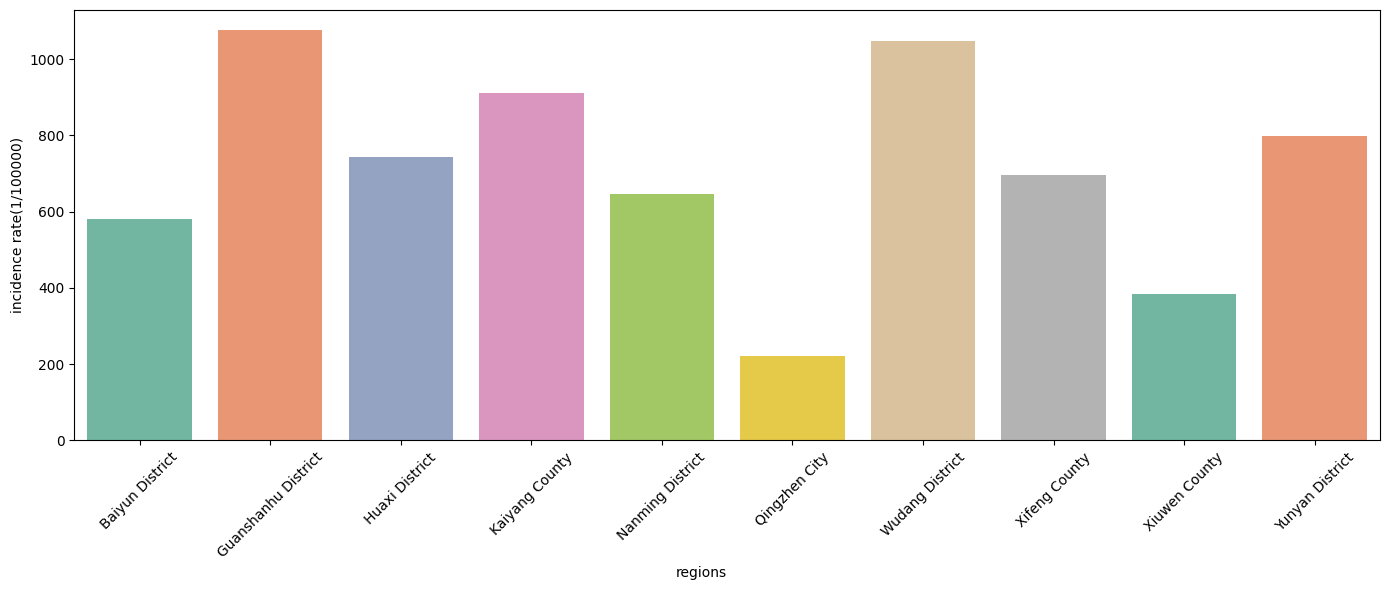

不同职业HFMD发病率描述性指标:        2018year
count   4.000000
mean   25.000000
std    40.277235
min     0.858546
25%     2.214252
50%     7.063115
75%    29.848863
max    85.015223


/tmp/ipykernel_968/2010843279.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Population',y=PopY,data=PopulationIRDF,palette="Set2")


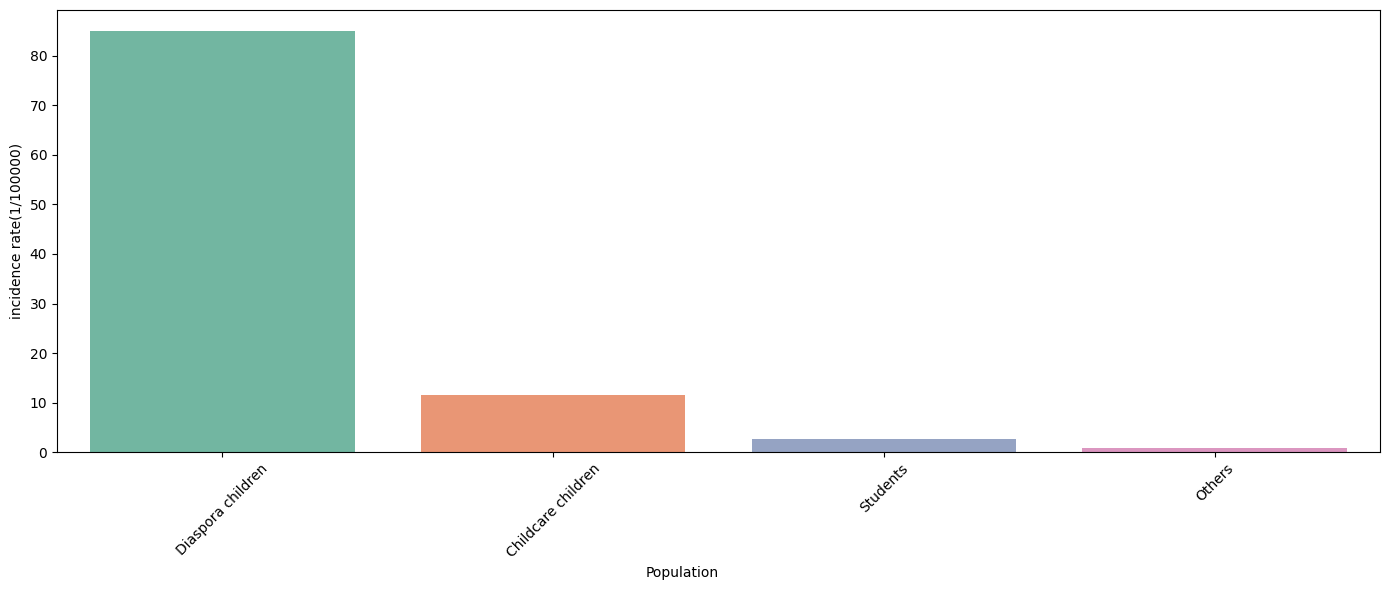

In [33]:
#统计不同职业和人群的患病差异-2018
import matplotlib.pyplot as plt
Describe(RegionalIRDF=RegionalIRDF.loc[:,['Regional','2018year']],RegY='2018year',
         PopulationIRDF=PopulationIRDF.loc[:,['Population','2018year']],PopY='2018year')

不同地区HFMD发病率描述性指标:          2019year
count    10.000000
mean    703.869012
std     389.254032
min     226.475922
25%     387.248676
50%     686.886359
75%     901.161275
max    1519.354297


/tmp/ipykernel_968/2010843279.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Regional',y=RegY,data=RegionalIRDF,palette="Set2")


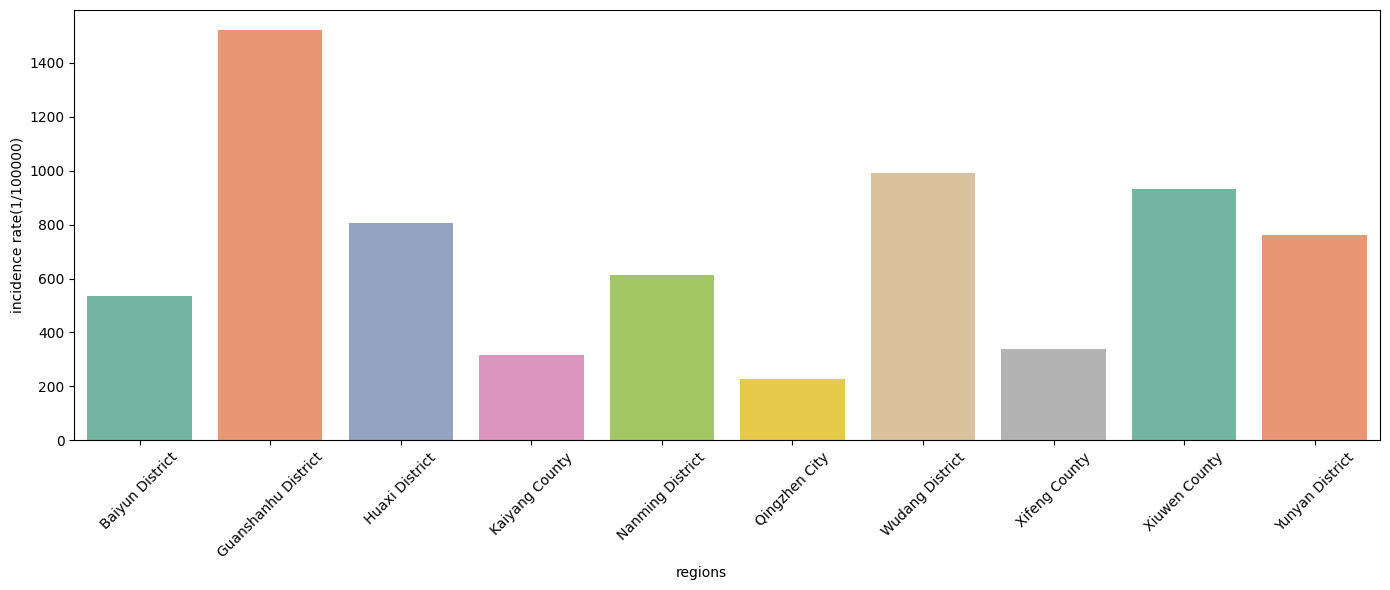

不同职业HFMD发病率描述性指标:        2019year
count   4.000000
mean   25.000000
std    40.709590
min     0.830364
25%     2.449986
50%     6.708687
75%    29.258701
max    85.752261


/tmp/ipykernel_968/2010843279.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Population',y=PopY,data=PopulationIRDF,palette="Set2")


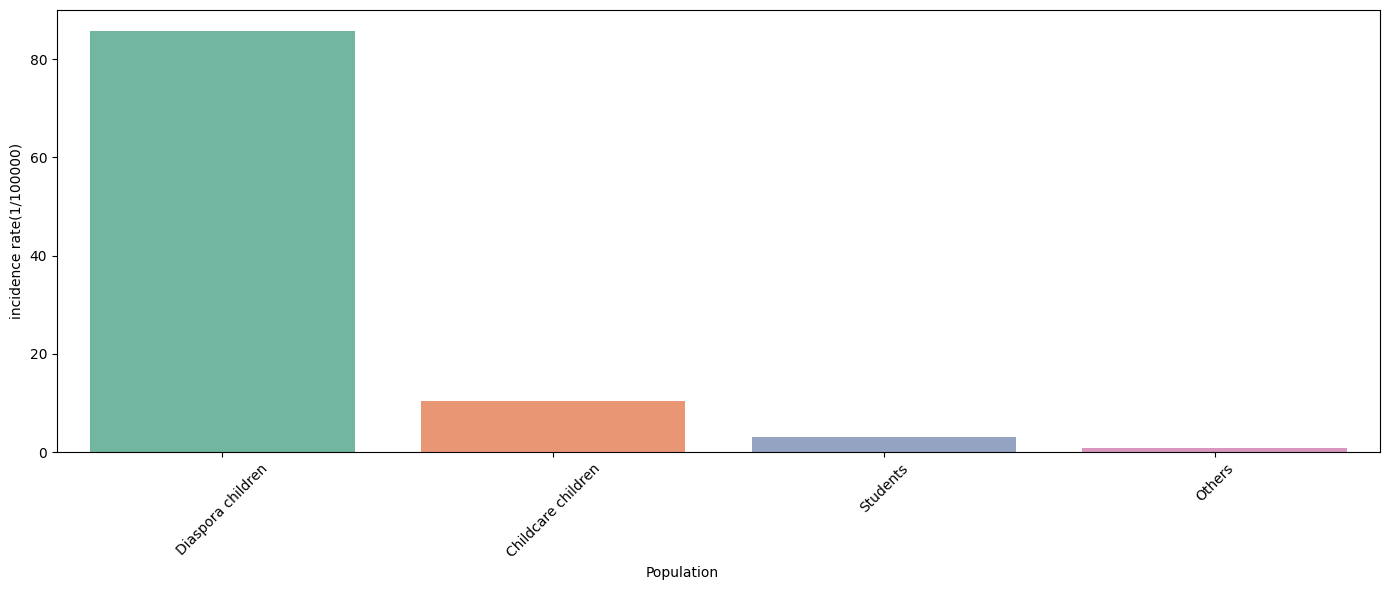

In [34]:
#统计不同职业和人群的患病差异-2019
Describe(RegionalIRDF=RegionalIRDF.loc[:,['Regional','2019year']],RegY='2019year',
         PopulationIRDF=PopulationIRDF.loc[:,['Population','2019year']],PopY='2019year')

不同地区HFMD发病率描述性指标:         2020year
count   10.000000
mean   334.707077
std    158.174891
min     78.345907
25%    255.191332
50%    355.711661
75%    385.938341
max    620.311209


/tmp/ipykernel_968/2010843279.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Regional',y=RegY,data=RegionalIRDF,palette="Set2")


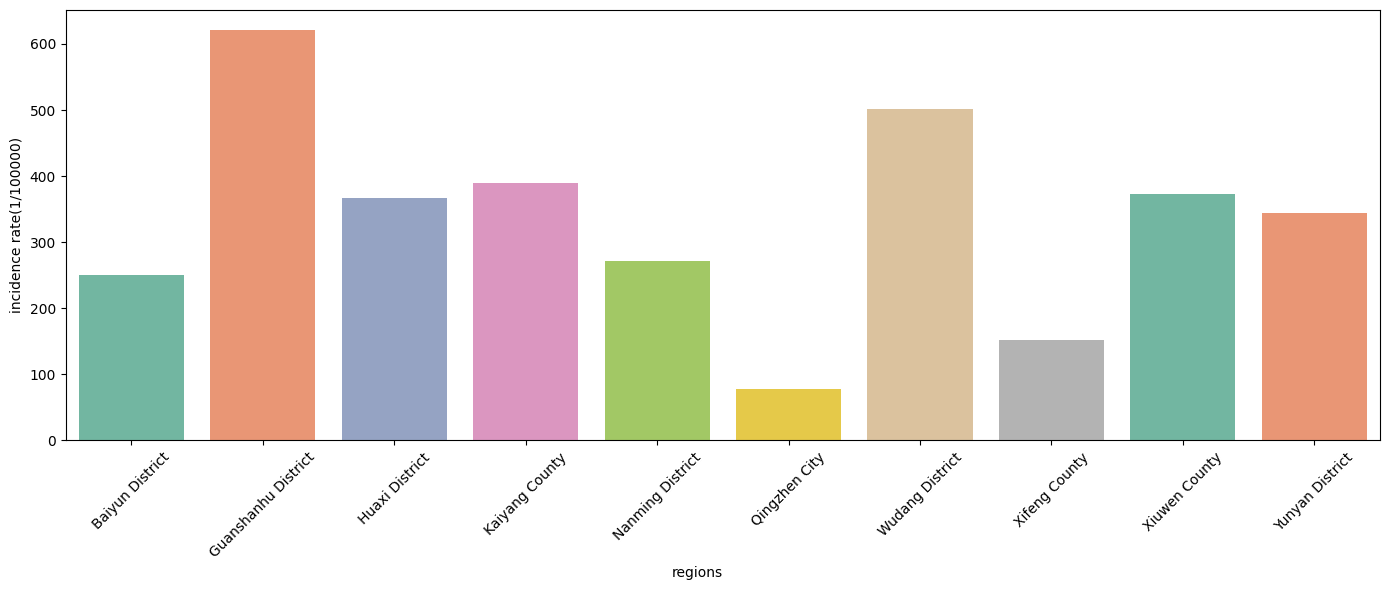

不同职业HFMD发病率描述性指标:        2020year
count   4.000000
mean   25.000000
std    35.905774
min     0.998110
25%     2.792051
50%    10.663241
75%    32.871191
max    77.675408


/tmp/ipykernel_968/2010843279.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Population',y=PopY,data=PopulationIRDF,palette="Set2")


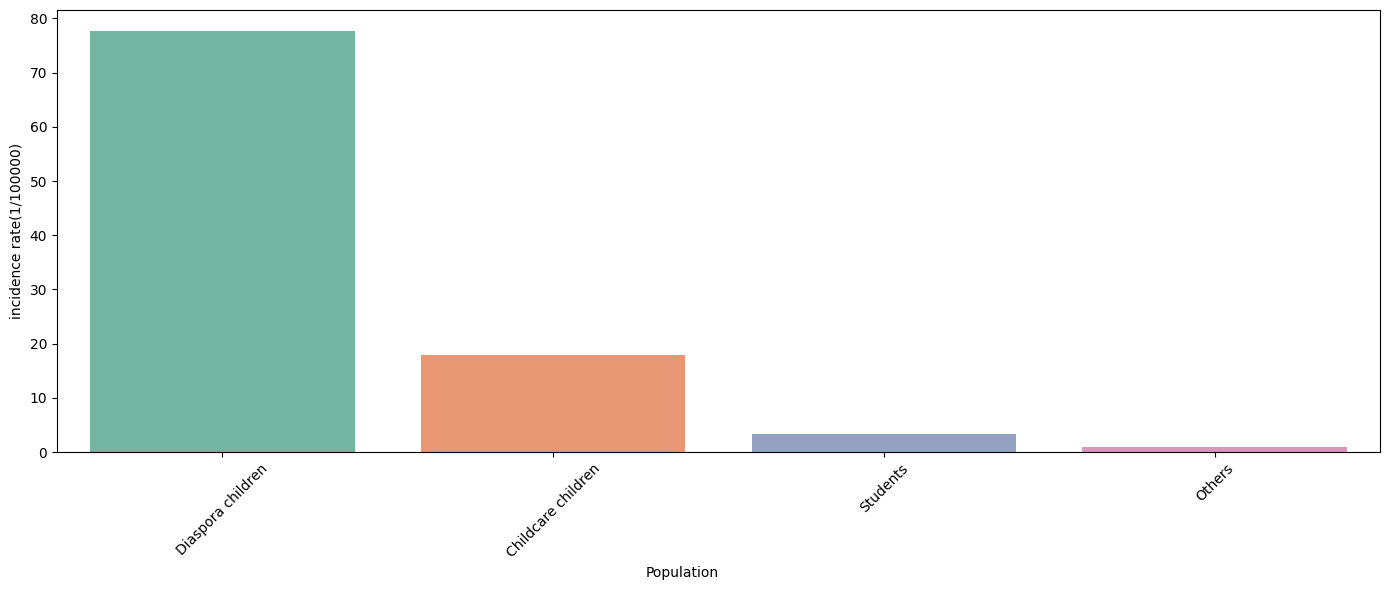

In [35]:
#统计不同职业和人群的患病差异-2020
Describe(RegionalIRDF=RegionalIRDF.loc[:,['Regional','2020year']],RegY='2020year',
         PopulationIRDF=PopulationIRDF.loc[:,['Population','2020year']],PopY='2020year')

不同地区HFMD发病率描述性指标:         2021year
count   10.000000
mean   230.582129
std    102.181640
min     48.482729
25%    159.500236
50%    257.163204
75%    289.090756
max    372.453053


/tmp/ipykernel_968/2010843279.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Regional',y=RegY,data=RegionalIRDF,palette="Set2")


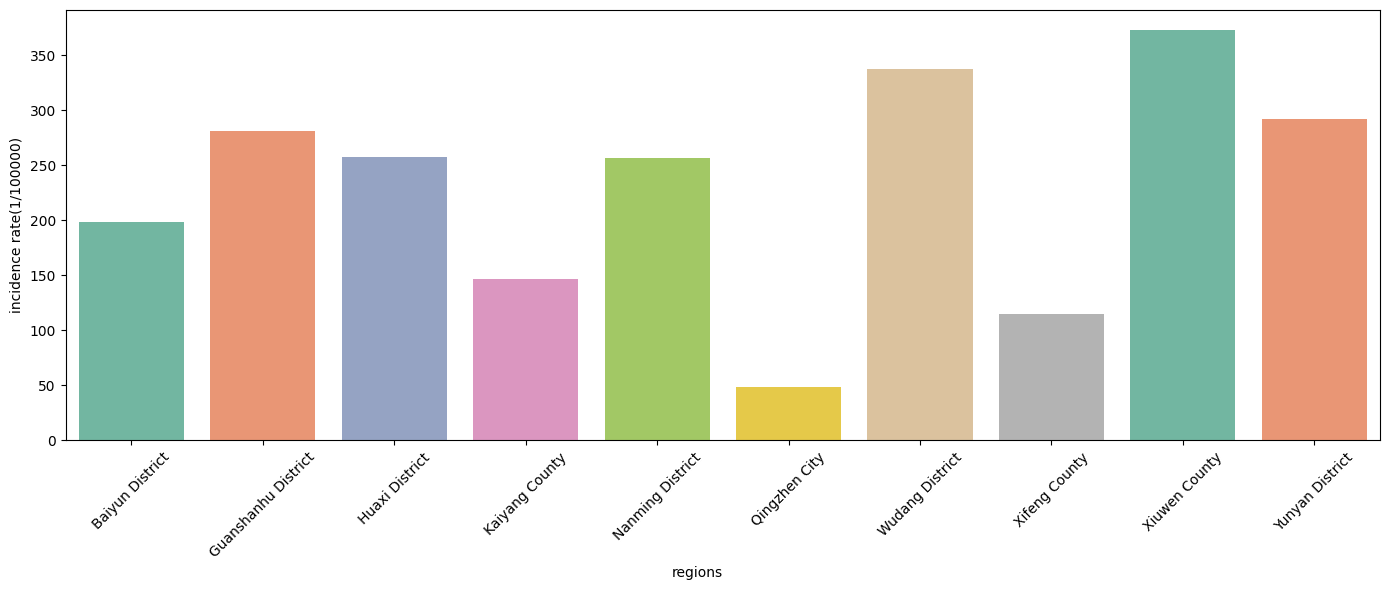

不同职业HFMD发病率描述性指标:        2021year
count   4.000000
mean   25.000000
std    28.995708
min     0.698149
25%     3.889218
50%    17.799513
75%    38.910294
max    63.702826


/tmp/ipykernel_968/2010843279.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Population',y=PopY,data=PopulationIRDF,palette="Set2")


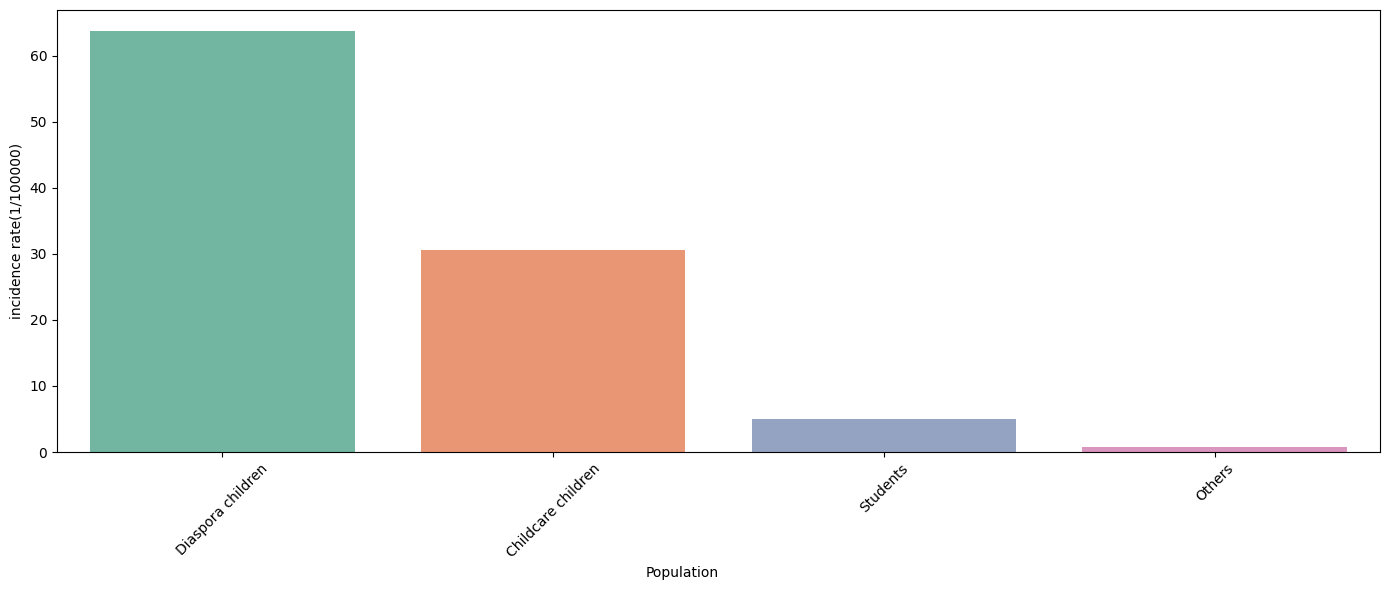

In [36]:
#统计不同职业和人群的患病差异-2021
Describe(RegionalIRDF=RegionalIRDF.loc[:,['Regional','2021year']],RegY='2021year',
         PopulationIRDF=PopulationIRDF.loc[:,['Population','2021year']],PopY='2021year')

不同地区HFMD发病率描述性指标:         2022year
count   10.000000
mean   264.090758
std     98.085385
min     65.054602
25%    214.970940
50%    271.946198
75%    306.913493
max    415.364002


/tmp/ipykernel_968/2010843279.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Regional',y=RegY,data=RegionalIRDF,palette="Set2")


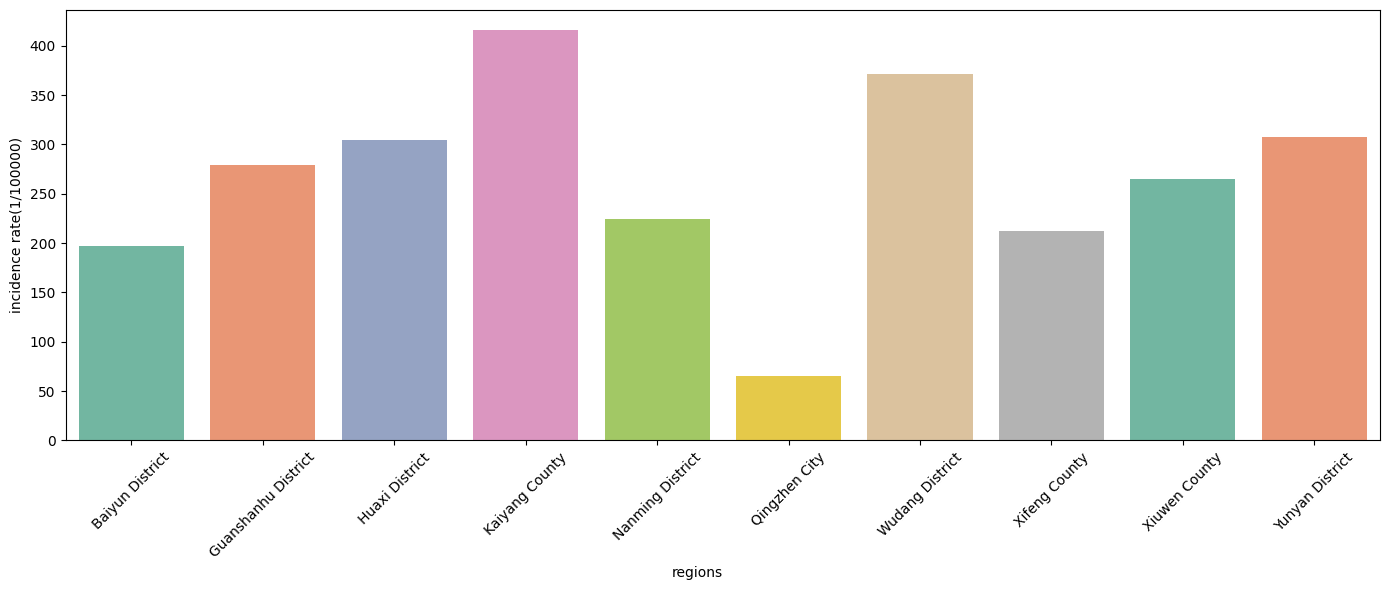

不同职业HFMD发病率描述性指标:        2022year
count   4.000000
mean   25.000000
std    27.428909
min     0.921995
25%     4.454099
50%    19.484611
75%    40.030512
max    60.108782


/tmp/ipykernel_968/2010843279.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Population',y=PopY,data=PopulationIRDF,palette="Set2")


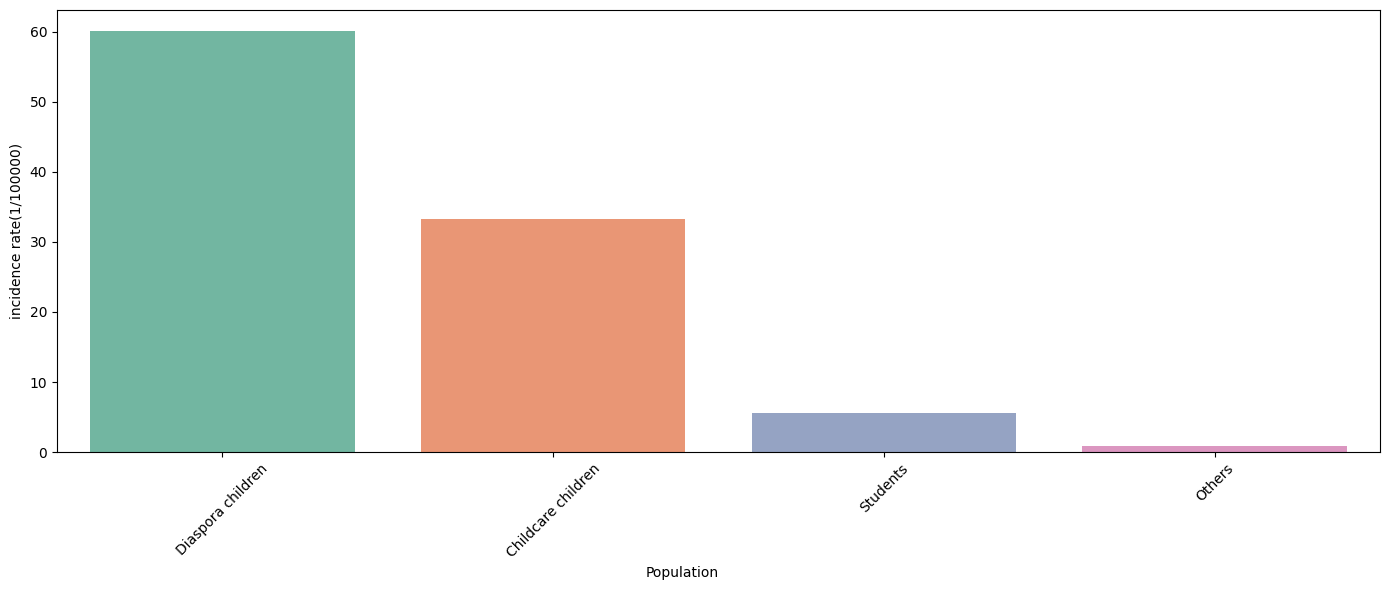

In [37]:
#统计不同职业和人群的患病差异-2022
Describe(RegionalIRDF=RegionalIRDF.loc[:,['Regional','2022year']],RegY='2022year',
         PopulationIRDF=PopulationIRDF.loc[:,['Population','2022year']],PopY='2022year')

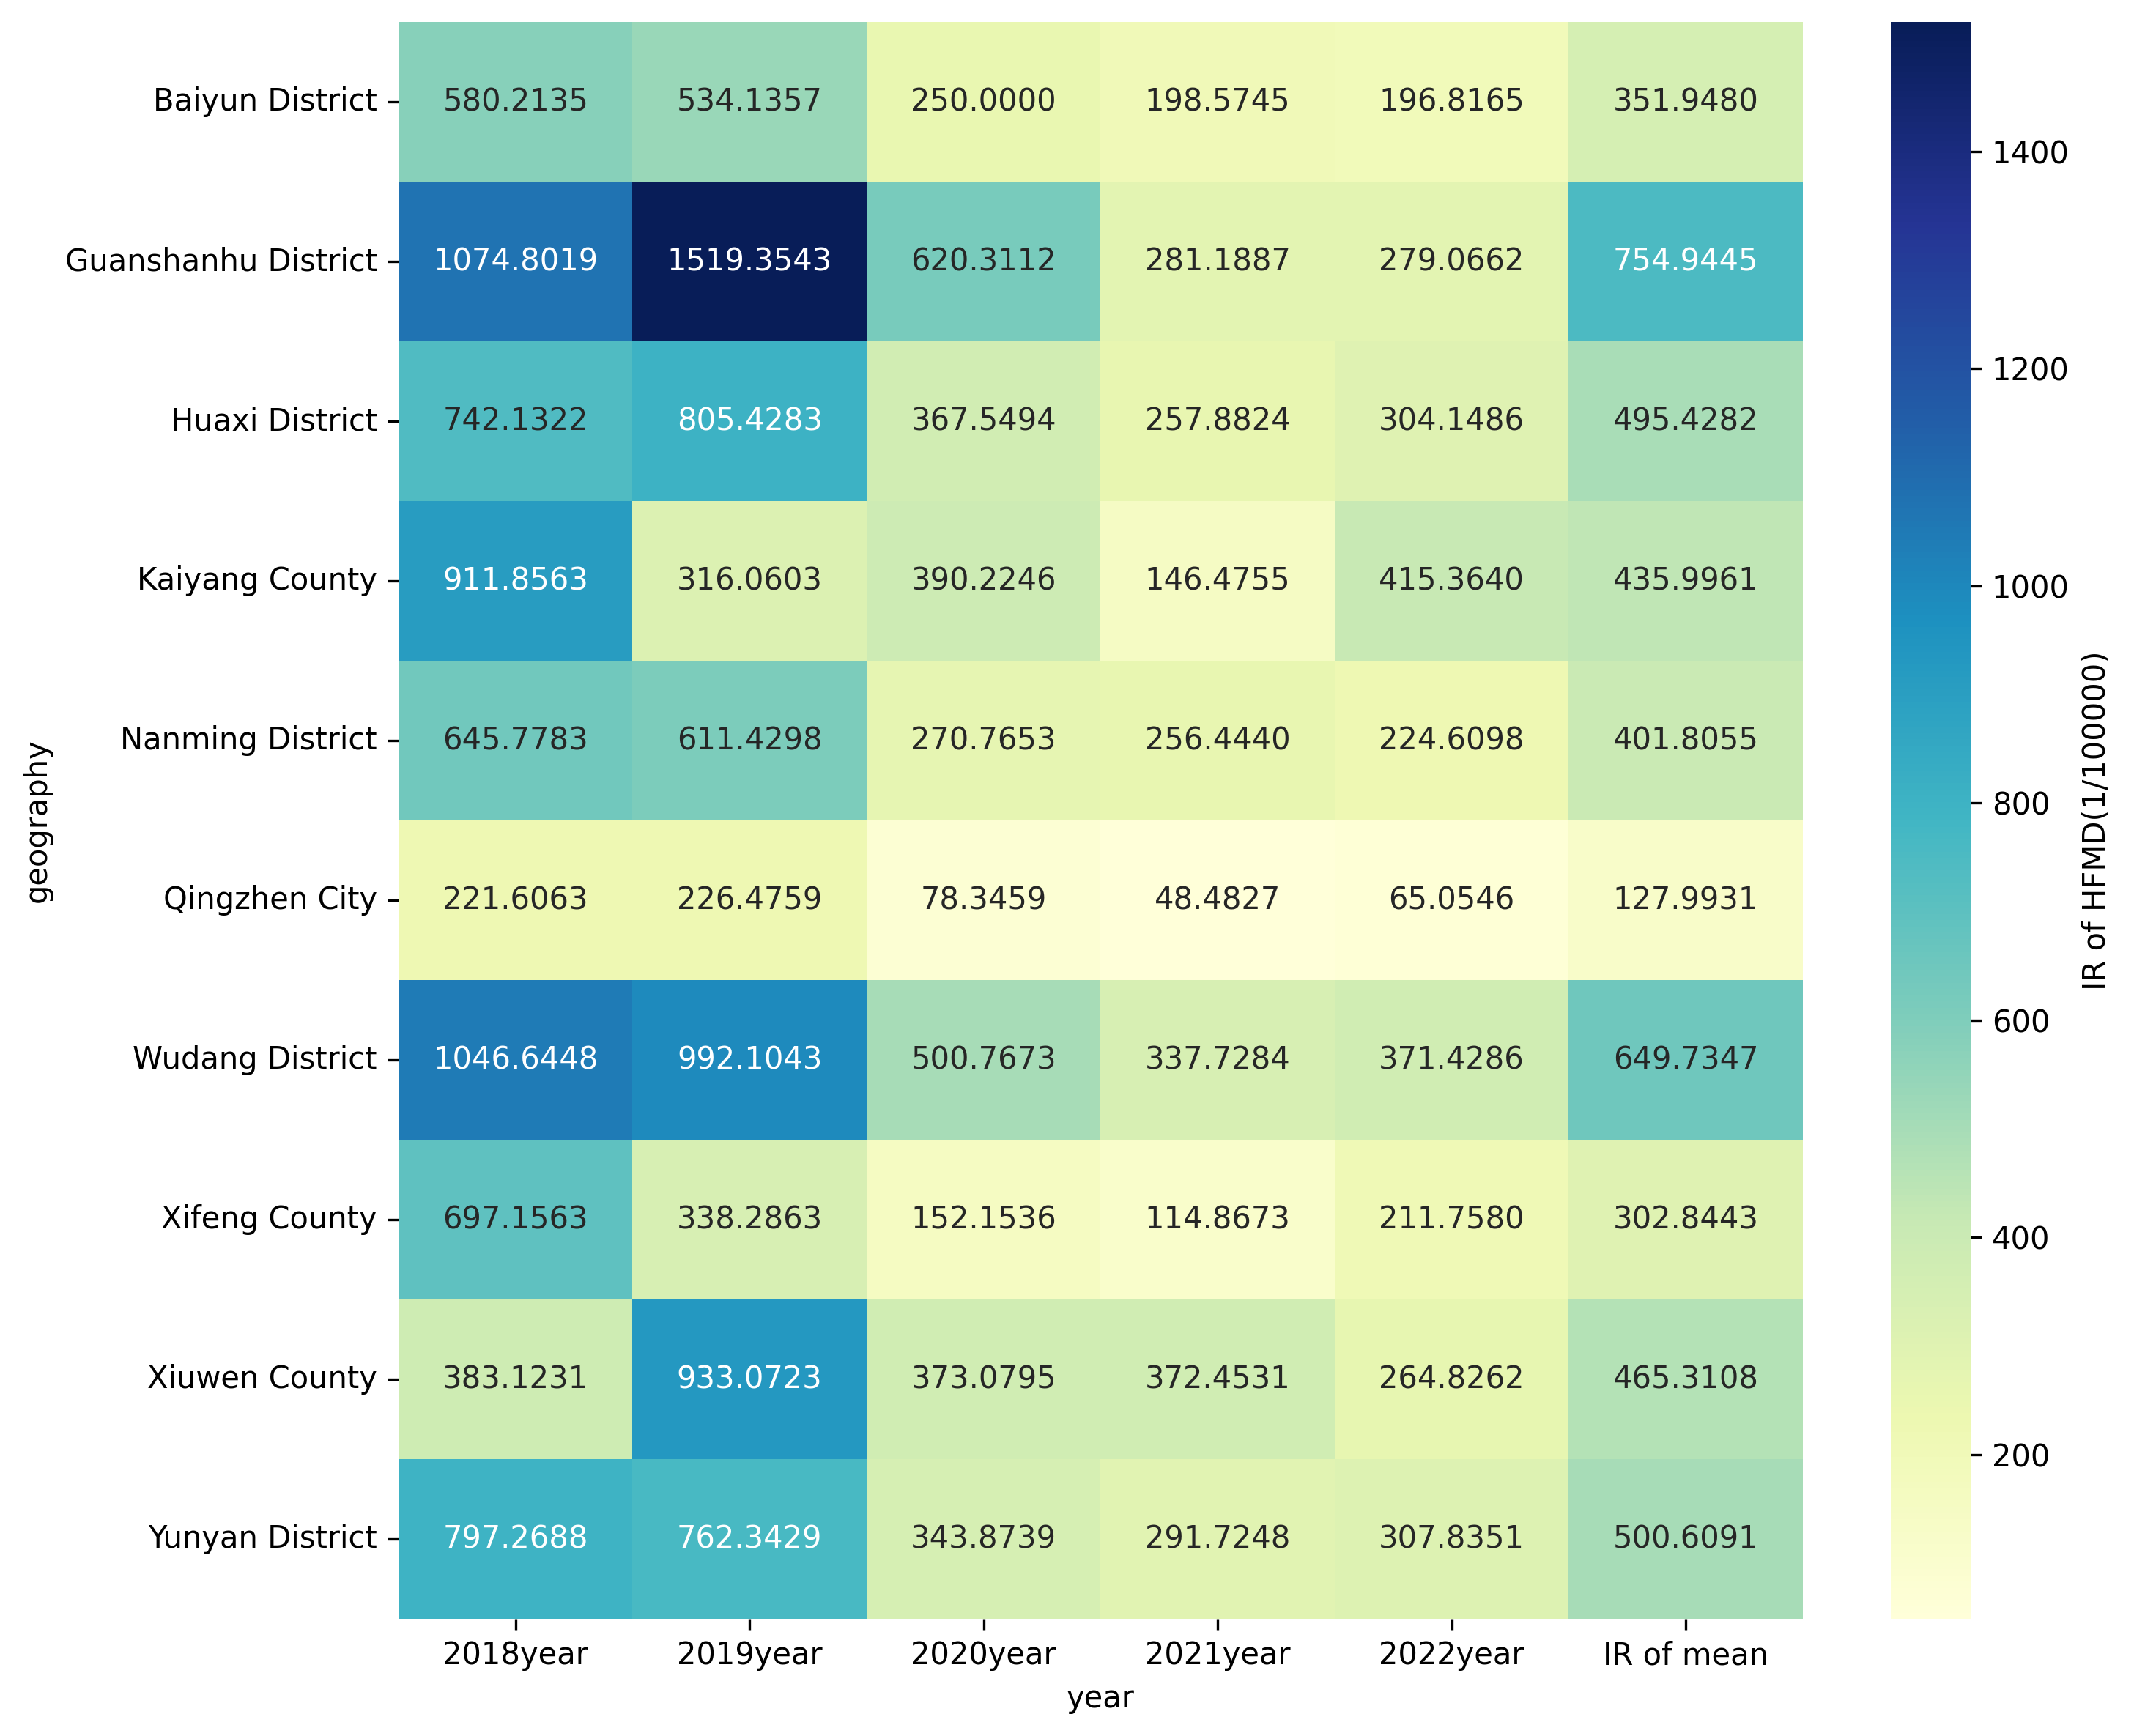

In [38]:
indexname=RegionalIRDF['Regional']
RegionalIRDF.index=indexname
RegionalIRDF.drop(labels=['Regional'],inplace=True,axis=1)
#绘制热力图
plt.figure(figsize=(10, 8),dpi=300)
RDF=sns.heatmap(RegionalIRDF, annot=True, cmap="YlGnBu", fmt=".4f")
cbar=RDF.collections[0].colorbar
cbar.set_label(label="IR of HFMD(1/100000)")
plt.title("")
plt.xlabel("year")
plt.ylabel("geography")
plt.tight_layout()
plt.show()

In [39]:
#比较不同地区HFMD发病率差异
from pandas import DataFrame
import scipy.stats as stats
from scipy.stats import shapiro, levene
Reg,Stats,Pavlue,RegData=[],[],[],[]    #正态性检验
for regional in RegionalIRDF.index:
    data=RegionalIRDF.loc[regional,['2018year','2019year','2020year','2021year','2022year']]
    stats,pvalue=shapiro(data)
    Reg.append(regional)
    Stats.append(stats)
    Pavlue.append(pvalue)
    RegData.append(list(data))
Normaltest=DataFrame()
Normaltest['Regional']=Reg
Normaltest['Stats']=Stats
Normaltest['P value']=Pavlue
levene_stat,levene_p=levene(*RegData)     #方差齐性检验
print(f'方差齐性检验统计量:{levene_stat},P值:{levene_p}')
Normaltest

方差齐性检验统计量:0.9252559469778323,P值:0.5139051446539872


,Regional,Stats,P value
0,Baiyun District,0.787056,0.063293
1,Guanshanhu District,0.893024,0.372538
2,Huaxi District,0.828119,0.134663
3,Kaiyang County,0.867247,0.255452
4,Nanming District,0.771904,0.046889
5,Qingzhen City,0.780609,0.055787
6,Wudang District,0.817420,0.111517
7,Xifeng County,0.836343,0.155065
8,Xiuwen County,0.705450,0.010910
9,Yunyan District,0.758586,0.035673


In [40]:
#输出正态检验结果
Normaltest.to_csv('/root/ToResult/Stage1DescriptiveAnalysis/RegionalNormaltest.csv',encoding='utf-8')

In [41]:
#采用方差分析
from scipy.stats import f_oneway,kruskal
ANOVA_stats,ANOVA_pvalue=f_oneway(*RegData)    #ANOVA
KWH_stats,KWH_pavlue=kruskal(*RegData)    #Kruskal-Wallis H 检验
print(f'ANOVA分析统计量:{ANOVA_stats},p值:{ANOVA_pvalue}')
print(f'Kruskal-Wallis H 检验统计量:{KWH_stats},p值:{KWH_pavlue}')

ANOVA分析统计量:1.8330012344107913,p值:0.0920219251394958
Kruskal-Wallis H 检验统计量:18.353411764705868,p值:0.03128780585641203


Dunn检验两两比较p值矩阵:


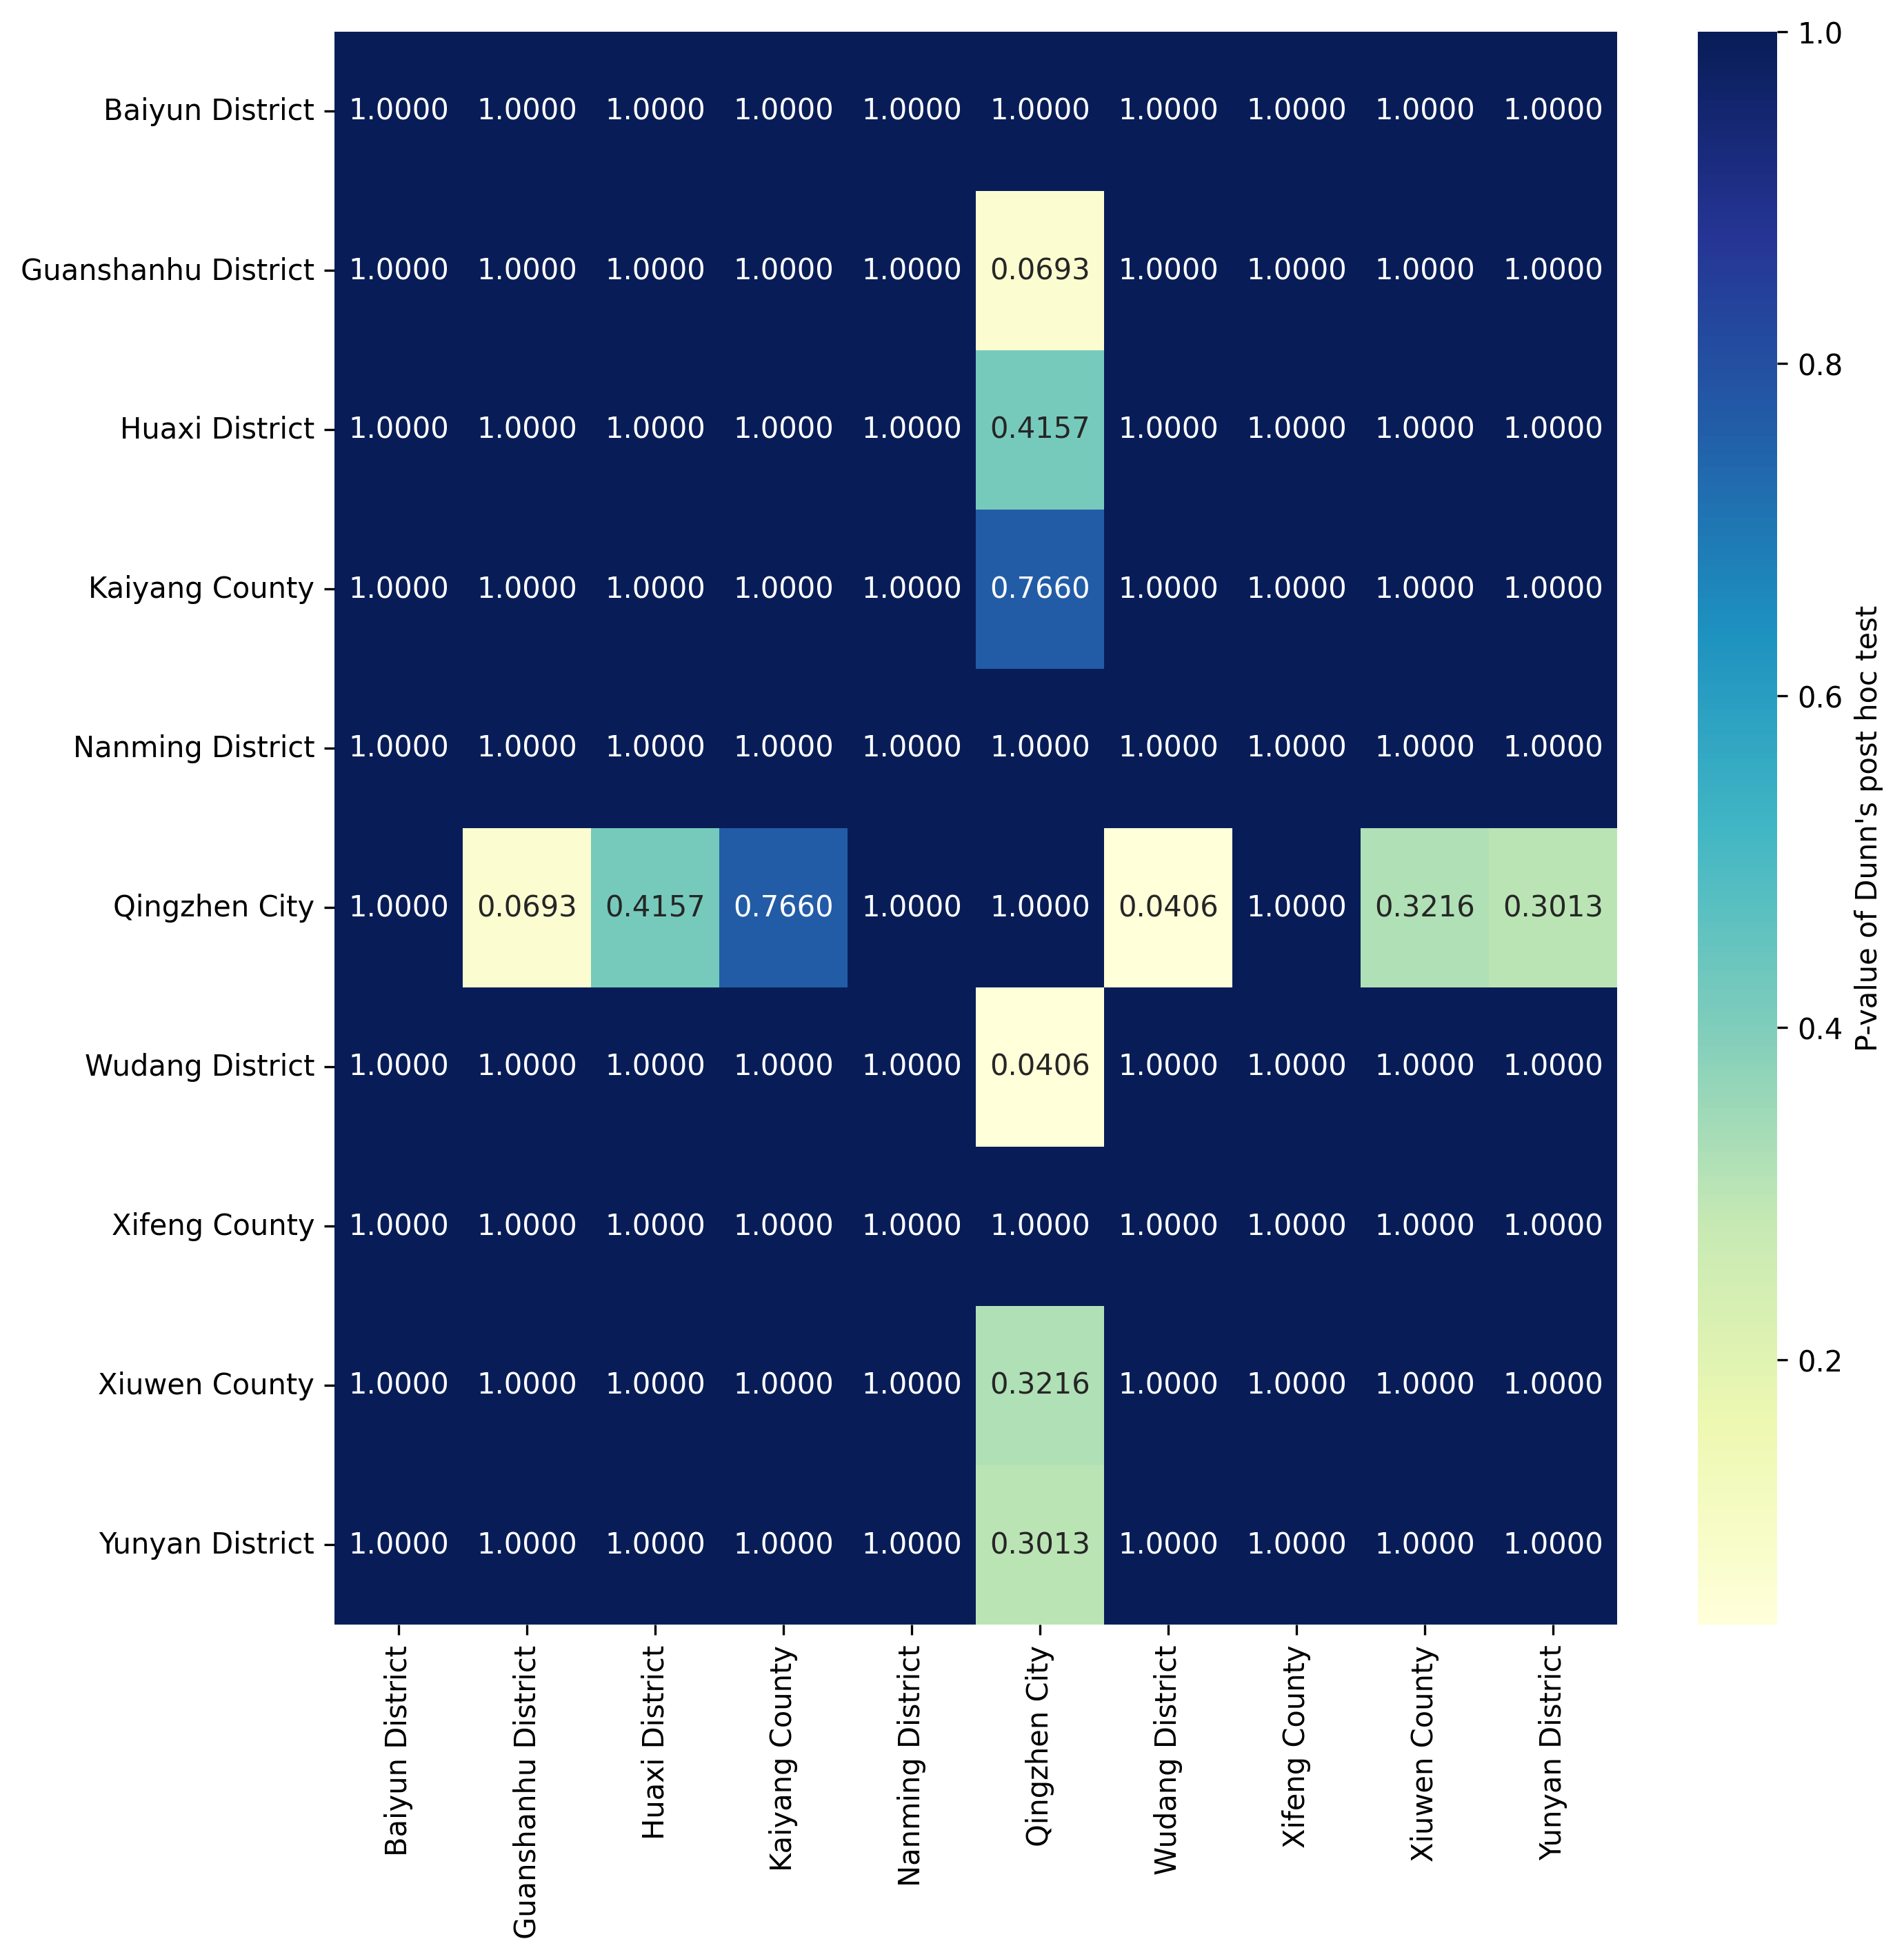

In [45]:
#事后检验
from scikit_posthocs import posthoc_dunn
RegionalIRDF['RegionalName']=RegionalIRDF.index
df_longReg= pd.melt(frame=RegionalIRDF,id_vars=["RegionalName"],value_vars=["2018year", "2019year", "2020year", "2021year", "2022year"], 
                    var_name="Year", value_name="IR")
dunn_result = posthoc_dunn(df_longReg,group_col="RegionalName",val_col='IR',p_adjust="bonferroni")
print("Dunn检验两两比较p值矩阵:")
plt.figure(figsize=(10,10),dpi=300)
dunn_1=sns.heatmap(dunn_result,annot=True, cmap="YlGnBu", fmt=".4f")
cbar=dunn_1.collections[0].colorbar
cbar.set_label(label="P-value of Dunn's post hoc test")

In [46]:
#输出事后比较结果
dunn_result.to_csv('/root/ToResult/Stage1DescriptiveAnalysis/RegionalDunn.csv',encoding='utf-8')

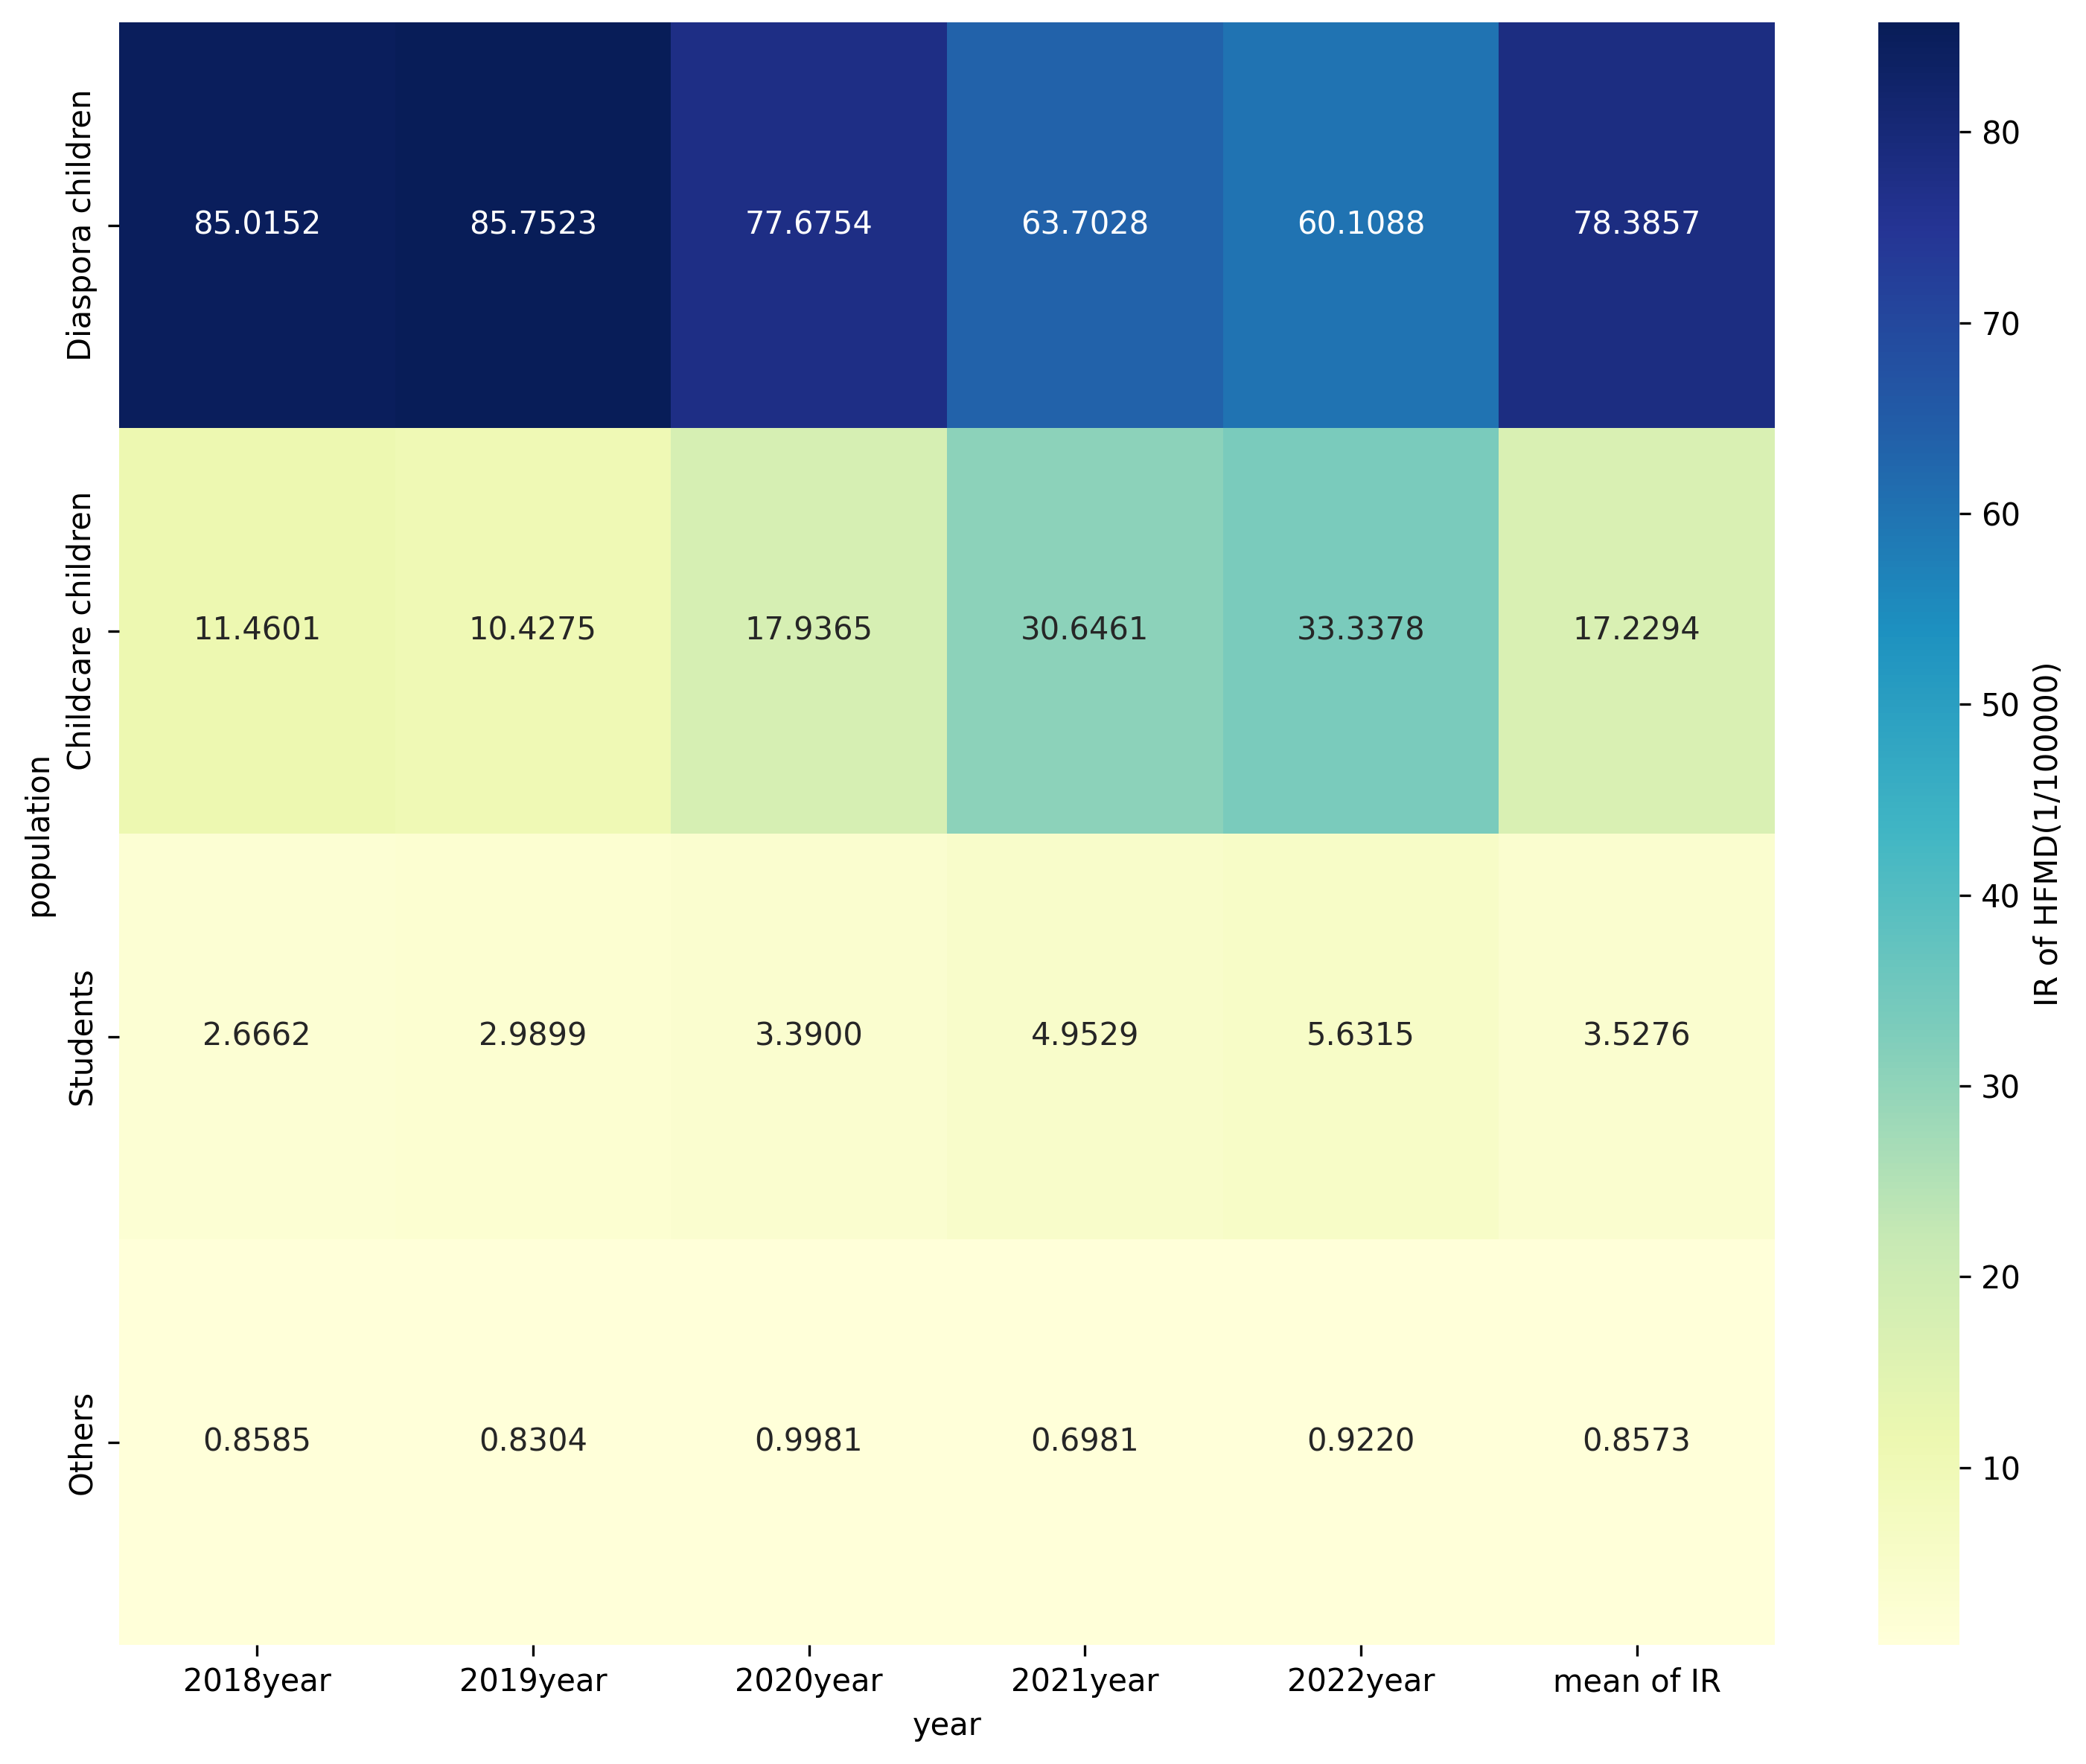

In [47]:
## 合并职业发病数据
IndexName=PopulationIRDF['Population']
PopulationIRDF.index=IndexName
PopulationIRDF.drop(labels=['Population'],inplace=True,axis=1)
#绘制热力图
plt.figure(figsize=(10, 8),dpi=300)
popu_ax=sns.heatmap(PopulationIRDF, annot=True, cmap="YlGnBu", fmt=".4f")
popu_cbar=popu_ax.collections[0].colorbar
popu_cbar.set_label(label="IR of HFMD(1/100000)")
plt.title("")
plt.xlabel("year")
plt.ylabel("population")
plt.tight_layout()
plt.show()

In [48]:
#分析职业年龄发病
Pop,PStats,PPavlue,PopData=[],[],[],[]    #正态性检验
for population in PopulationIRDF.index:
    data=PopulationIRDF.loc[population,['2018year','2019year','2020year','2021year','2022year']]
    stats,pvalue=shapiro(data)
    Pop.append(population)
    PStats.append(stats)
    PPavlue.append(pvalue)
    PopData.append(list(data))
NormaltestP=DataFrame()
NormaltestP['Population']=Pop
NormaltestP['Stats']=PStats
NormaltestP['P value']=PPavlue
levene_stat_pop,levene_p_pop=levene(*PopData)     #方差齐性检验
print(f'方差齐性检验统计量:{levene_stat_pop},P值:{levene_p_pop}')
NormaltestP

方差齐性检验统计量:5.773460253242109,P值:0.007138561376825599


,Population,Stats,P value
0,Diaspora children,0.862245,0.236421
1,Childcare children,0.862575,0.237642
2,Students,0.890139,0.357803
3,Others,0.981406,0.941997


In [49]:
#输出人群正态检验结果
NormaltestP.to_csv('/root/ToResult/Stage1DescriptiveAnalysis/PopulationNormaltest.csv',encoding='utf-8')

In [50]:
KWH_stats_pop,KWH_pavlue_pop=kruskal(*PopData)    #Kruskal-Wallis H 检验
print(f'Kruskal-Wallis H 检验统计量:{KWH_stats_pop},p值:{KWH_pavlue_pop}')

Kruskal-Wallis H 检验统计量:17.85714285714286,p值:0.0004707189529993288


Dunn检验两两比较p值矩阵:


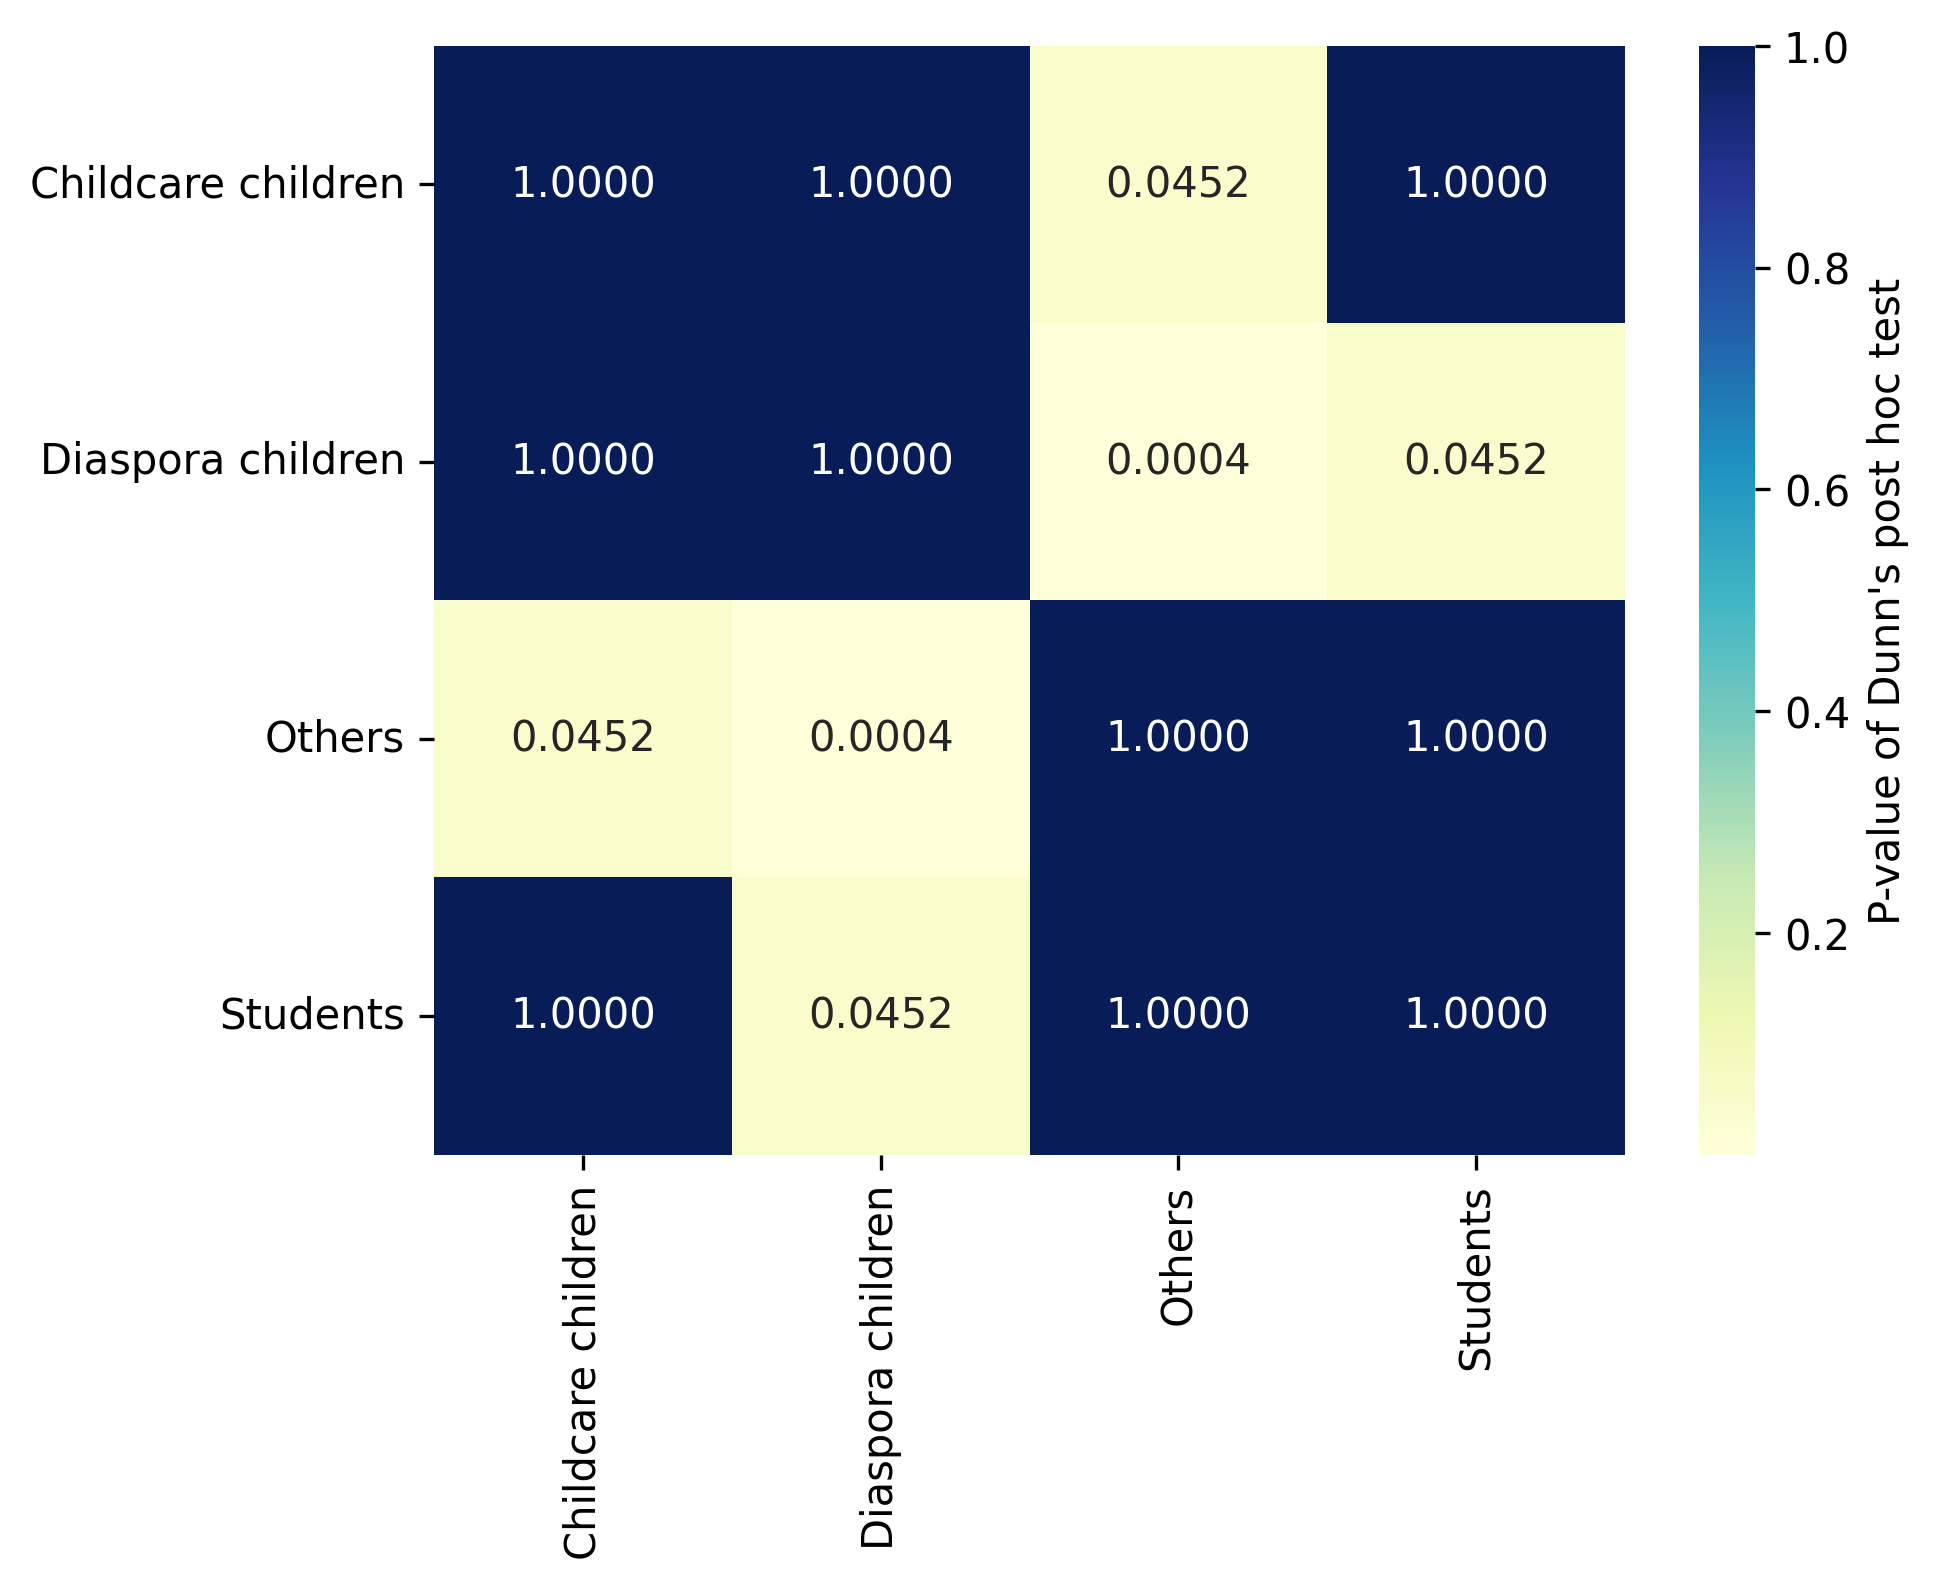

In [51]:
#事后比较
PopulationIRDF['PopulationName']=PopulationIRDF.index
df_long =pd.melt(frame=PopulationIRDF,id_vars=["PopulationName"],value_vars=["2018year", "2019year", "2020year", "2021year", "2022year"],  
                 var_name="Year", value_name="IR" )
dunn_resultPop=posthoc_dunn(df_long,group_col="PopulationName",val_col='IR',p_adjust="bonferroni")
print("Dunn检验两两比较p值矩阵:")
plt.figure(dpi=300)
popu_dunn=sns.heatmap(dunn_resultPop,annot=True, cmap="YlGnBu", fmt=".4f")
popu_cbar=popu_dunn.collections[0].colorbar
popu_cbar.set_label(label="P-value of Dunn's post hoc test")

In [52]:
#输出事后检验结果
dunn_resultPop.to_csv('/root/ToResult/Stage1DescriptiveAnalysis/PopulationDunn.csv',encoding='utf-8')

分析不同年龄HFMD发病率差异

In [53]:
#分析年龄分布差异
import pandas as pd
AgeData=pd.read_csv('/root/AnalysisData/Age Distribution.csv',index_col='Age Range')

In [54]:
AgeData.drop(labels=['IR of mean'],axis=1,inplace=True)

In [55]:
#描述性指标
AgeData.describe()

,2018year,2019year,2020year,2021year,2022year
count,7.000000,7.000000,7.000000,7.000000,7.000000
mean,5208.142857,5212.857143,2418.857143,2169.000000,2153.714286
std,3343.067276,2756.254489,1538.312433,1035.558464,795.394811
min,1922.000000,2208.000000,713.000000,997.000000,1336.000000
25%,3095.000000,3508.000000,1426.000000,1392.500000,1476.500000
50%,4377.000000,4061.000000,1846.000000,2076.000000,2092.000000
75%,6052.000000,6498.000000,3175.500000,2662.500000,2610.000000
max,11864.000000,10209.000000,5170.000000,4000.000000,3475.000000


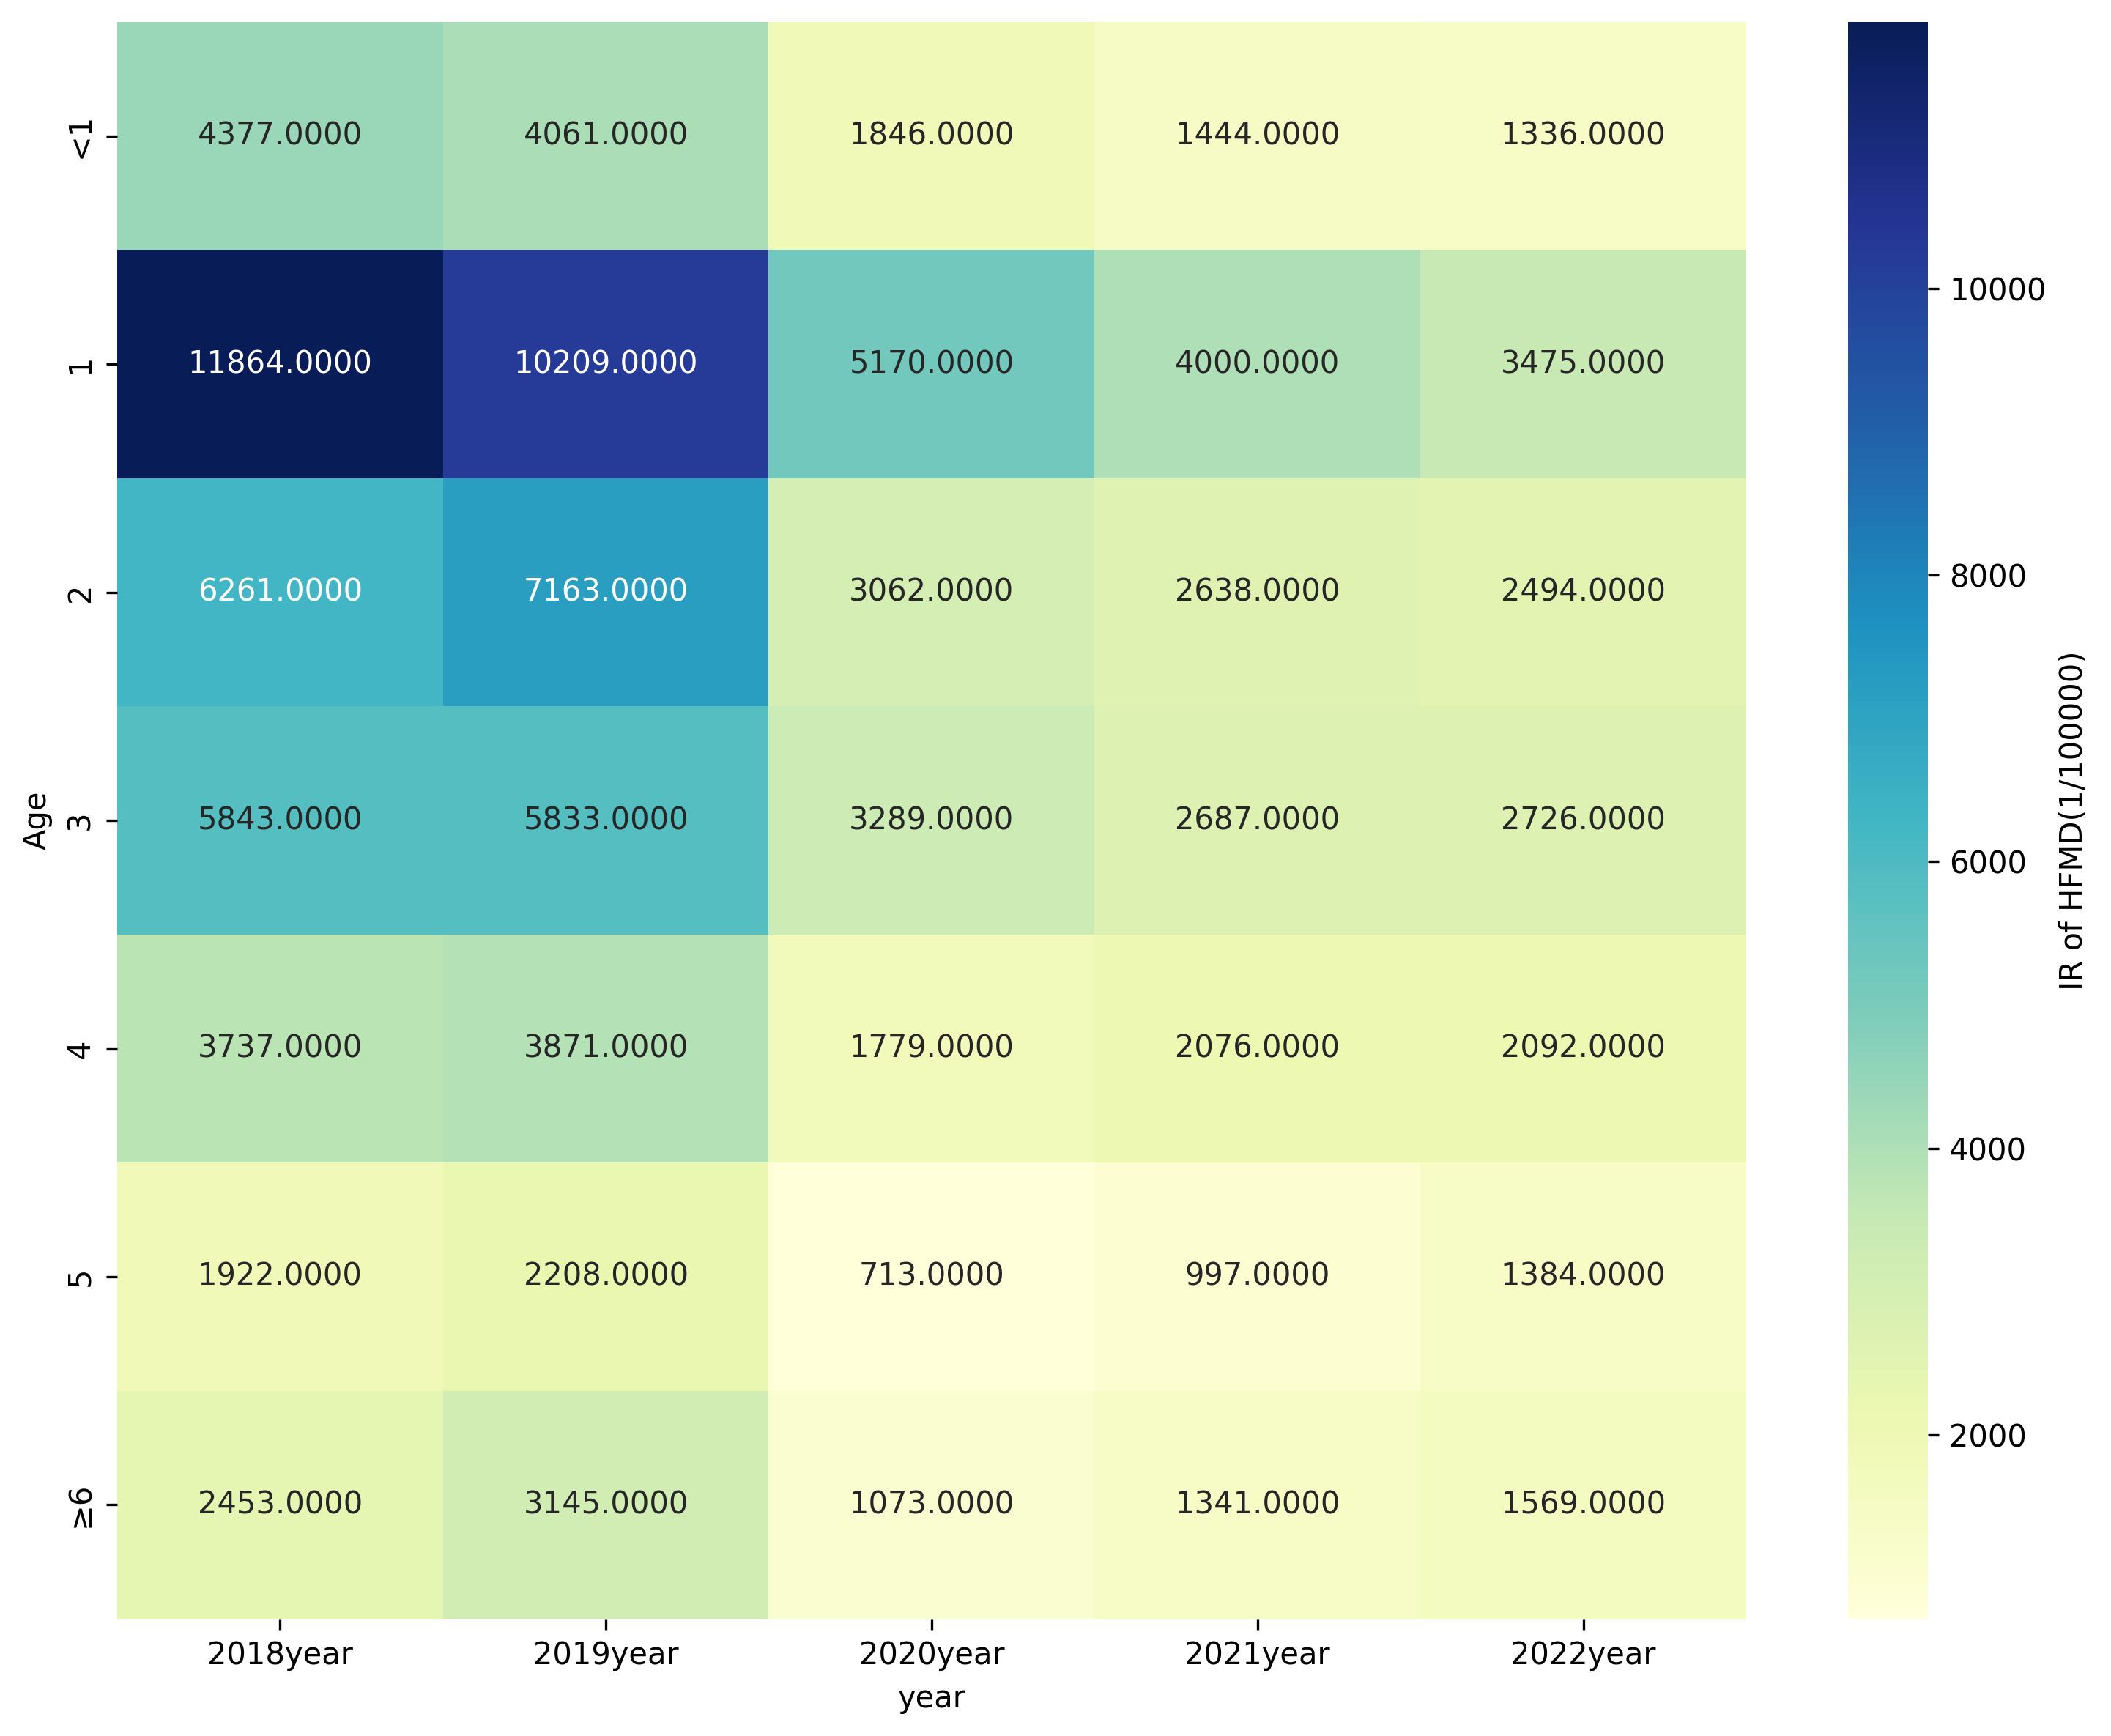

In [56]:
#绘制热力图
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 8),dpi=300)
age=sns.heatmap(AgeData, annot=True, cmap="YlGnBu", fmt=".4f")
cbar_age=age.collections[0].colorbar
cbar_age.set_label(label="IR of HFMD(1/100000)")
plt.title("")
plt.xlabel("year")
plt.ylabel("Age")
plt.tight_layout()
plt.show()

In [57]:
#进行统计学检验
from scipy.stats import shapiro,levene
from pandas import DataFrame
Age,AStats,APavlue,Agelist=[],[],[],[]    #正态性检验
for age in AgeData.index:
    data=AgeData.loc[age,['2018year','2019year','2020year','2021year','2022year']]
    stats,pvalue=shapiro(data)
    Age.append(age)
    AStats.append(stats)
    APavlue.append(pvalue)
    Agelist.append(list(data))
NormaltestA=DataFrame()
NormaltestA['Age']=Age
NormaltestA['Stats']=AStats
NormaltestA['P value']=APavlue
levene_stat_age,levene_p_age=levene(*Agelist)     #方差齐性检验
print(f'方差齐性检验统计量:{levene_stat_age},P值:{levene_p_age}')
NormaltestA

方差齐性检验统计量:1.57623191125626,P值:0.19098633750778157


,Age,Stats,P value
0,<1,0.800250,0.081416
1,1,0.852344,0.202041
2,2,0.807392,0.092965
3,3,0.766341,0.041876
4,4,0.791665,0.069180
5,5,0.955407,0.775695
6,≥6,0.914629,0.495900


In [58]:
#输出年龄正态检验结果
NormaltestA.to_csv('/root/ToResult/Stage1DescriptiveAnalysis/AgeNormaltest.csv',encoding='utf-8')

In [59]:
#统计学检验
ANOVA_stats_Age,ANOVA_pvalue_Age=f_oneway(*Agelist)    #ANOVA
KWH_stats_Age,KWH_pavlue_Age=kruskal(*Agelist)    #Kruskal-Wallis H 检验
print(f'ANOVA分析统计量:{ANOVA_stats_Age},p值:{ANOVA_pvalue_Age}')
print(f'Kruskal-Wallis H 检验统计量:{KWH_stats_Age},p值:{KWH_pavlue_Age}')

ANOVA分析统计量:4.60698457643424,p值:0.0022613926427614396
Kruskal-Wallis H 检验统计量:18.58666666666666,p值:0.004921737160698857


Dunn检验两两比较p值矩阵:


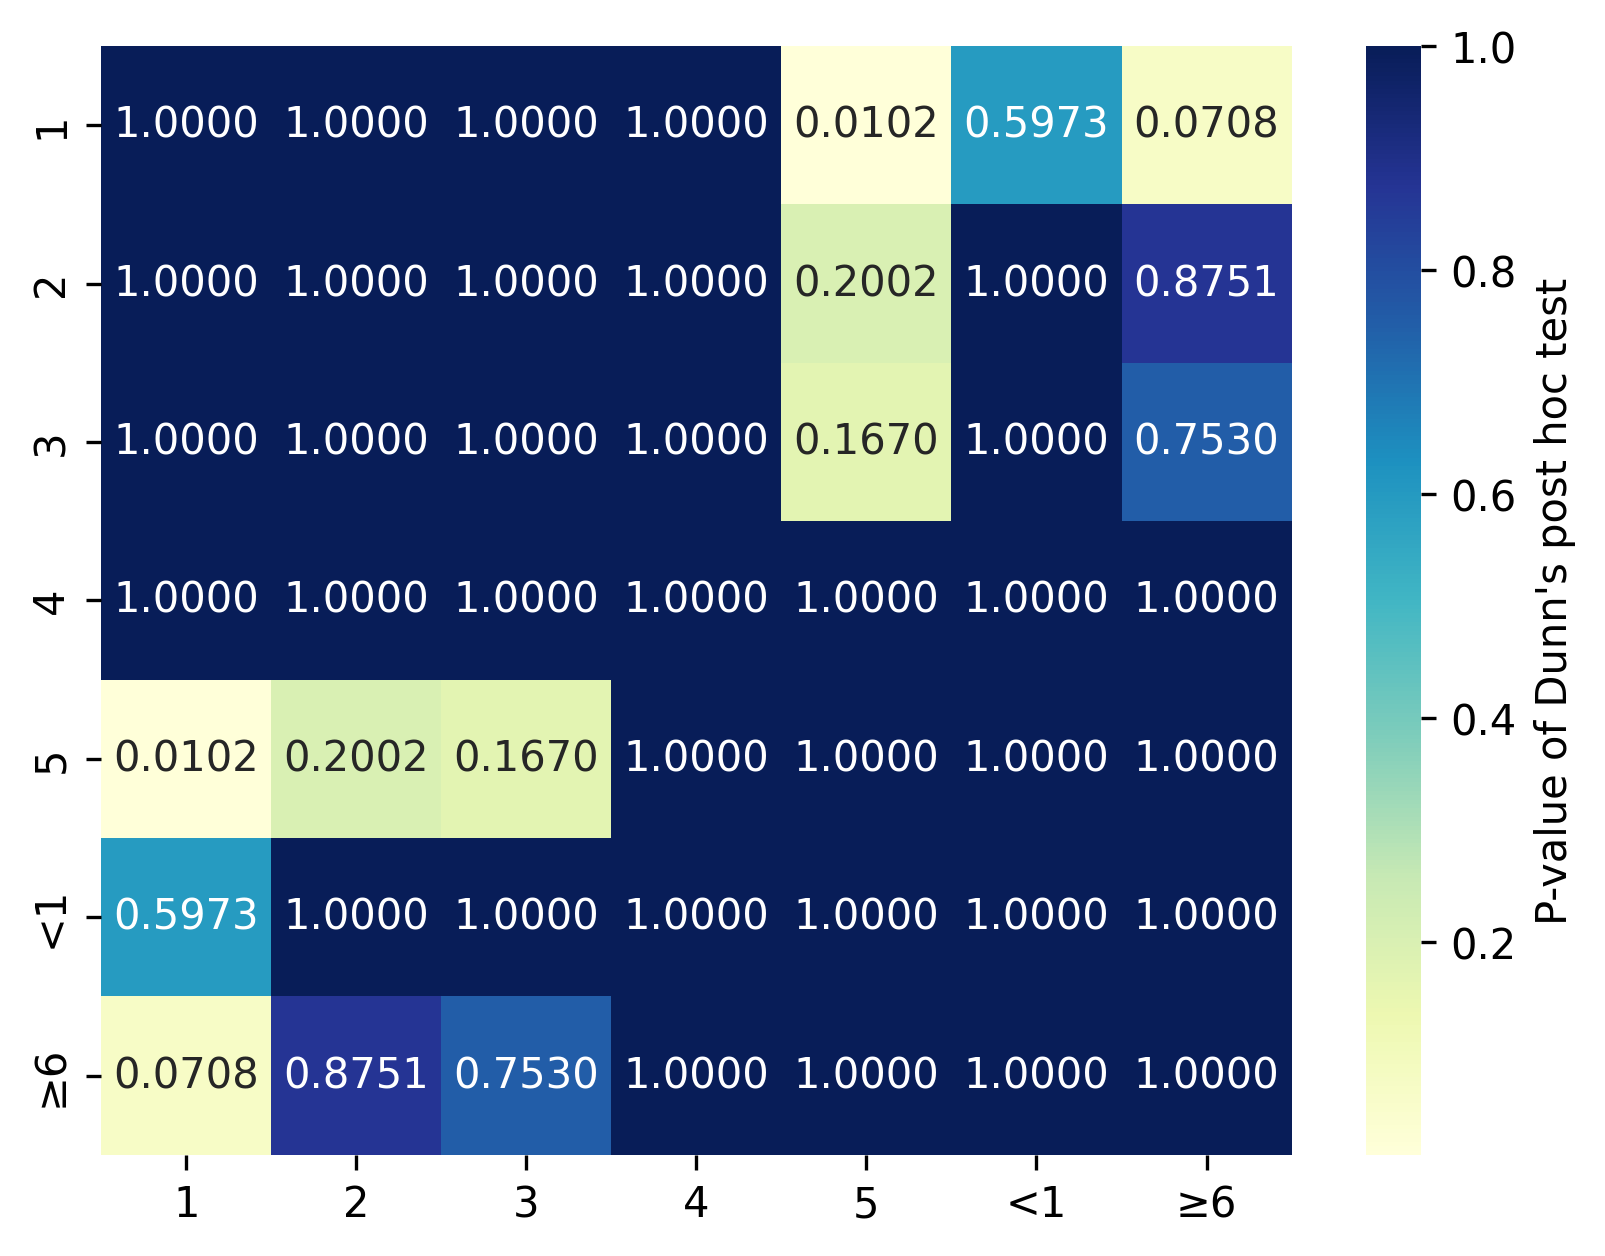

In [60]:
#事后检验
AgeData['AgeRangeName']=AgeData.index
df_long_Age=pd.melt(frame=AgeData,id_vars=["AgeRangeName"],value_vars=["2018year", "2019year", "2020year", "2021year", "2022year"],  
                 var_name="Year", value_name="IR" )
dunn_resultAge=posthoc_dunn(df_long_Age,group_col="AgeRangeName",val_col='IR',p_adjust="bonferroni")
print("Dunn检验两两比较p值矩阵:")
plt.figure(dpi=300)
age_dunn=sns.heatmap(dunn_resultAge,annot=True, cmap="YlGnBu", fmt=".4f")
age_cbar=age_dunn.collections[0].colorbar
age_cbar.set_label(label="P-value of Dunn's post hoc test")

In [61]:
#输出事后检验结果
dunn_resultAge.to_csv('/root/ToResult/Stage1DescriptiveAnalysis/AgeDunn.csv',encoding='utf-8')

分析发病率在时间维度上的分布，包括短期波动、周期性、季节性、长期趋势

In [62]:
#读取总发病率数据
import pandas as pd
AnalysisData=pd.read_csv('/root/AnalysisData/AnalysisData.csv',parse_dates=["Date"])
AnalysisData.info()

<class 'pandas.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Unnamed: 0         60 non-null     int64         
 1   Date               60 non-null     datetime64[us]
 2   Pressure(hPa)      60 non-null     float64       
 3   RH(%)              60 non-null     float64       
 4   WindSpeed(m/s)     60 non-null     float64       
 5   temperature_mean   60 non-null     float64       
 6   temperature_min    60 non-null     float64       
 7   temperature_max    60 non-null     float64       
 8   petPM(mm)          60 non-null     float64       
 9   precipitation(mm)  60 non-null     float64       
 10  IR                 60 non-null     float64       
dtypes: datetime64[us](1), float64(9), int64(1)
memory usage: 5.3 KB


In [63]:
AnalysisData=AnalysisData.set_index(AnalysisData['Date'])

In [64]:
#对HFMD发病率数据进行STL分解
#采用加法模型
from statsmodels.tsa.seasonal import STL
stl=STL(AnalysisData["IR"], robust=True)
stl_result=stl.fit()

In [65]:
#提取季节、趋势、和残差成分
from pandas import DataFrame
trend=stl_result.trend
seasonal=stl_result.seasonal 
resid=stl_result.resid
STLResult=DataFrame()    #整合STL结果
STLResult['Datetime']=AnalysisData['Date']
STLResult['IR']=AnalysisData['IR']
STLResult['trend']=trend
STLResult['seasonal']=seasonal
STLResult['resid']=resid

In [66]:
#输出STL分解数据
STLResult.to_csv('/root/ToResult/Stage1DescriptiveAnalysis/STLResultIR.csv',encoding='utf-8')

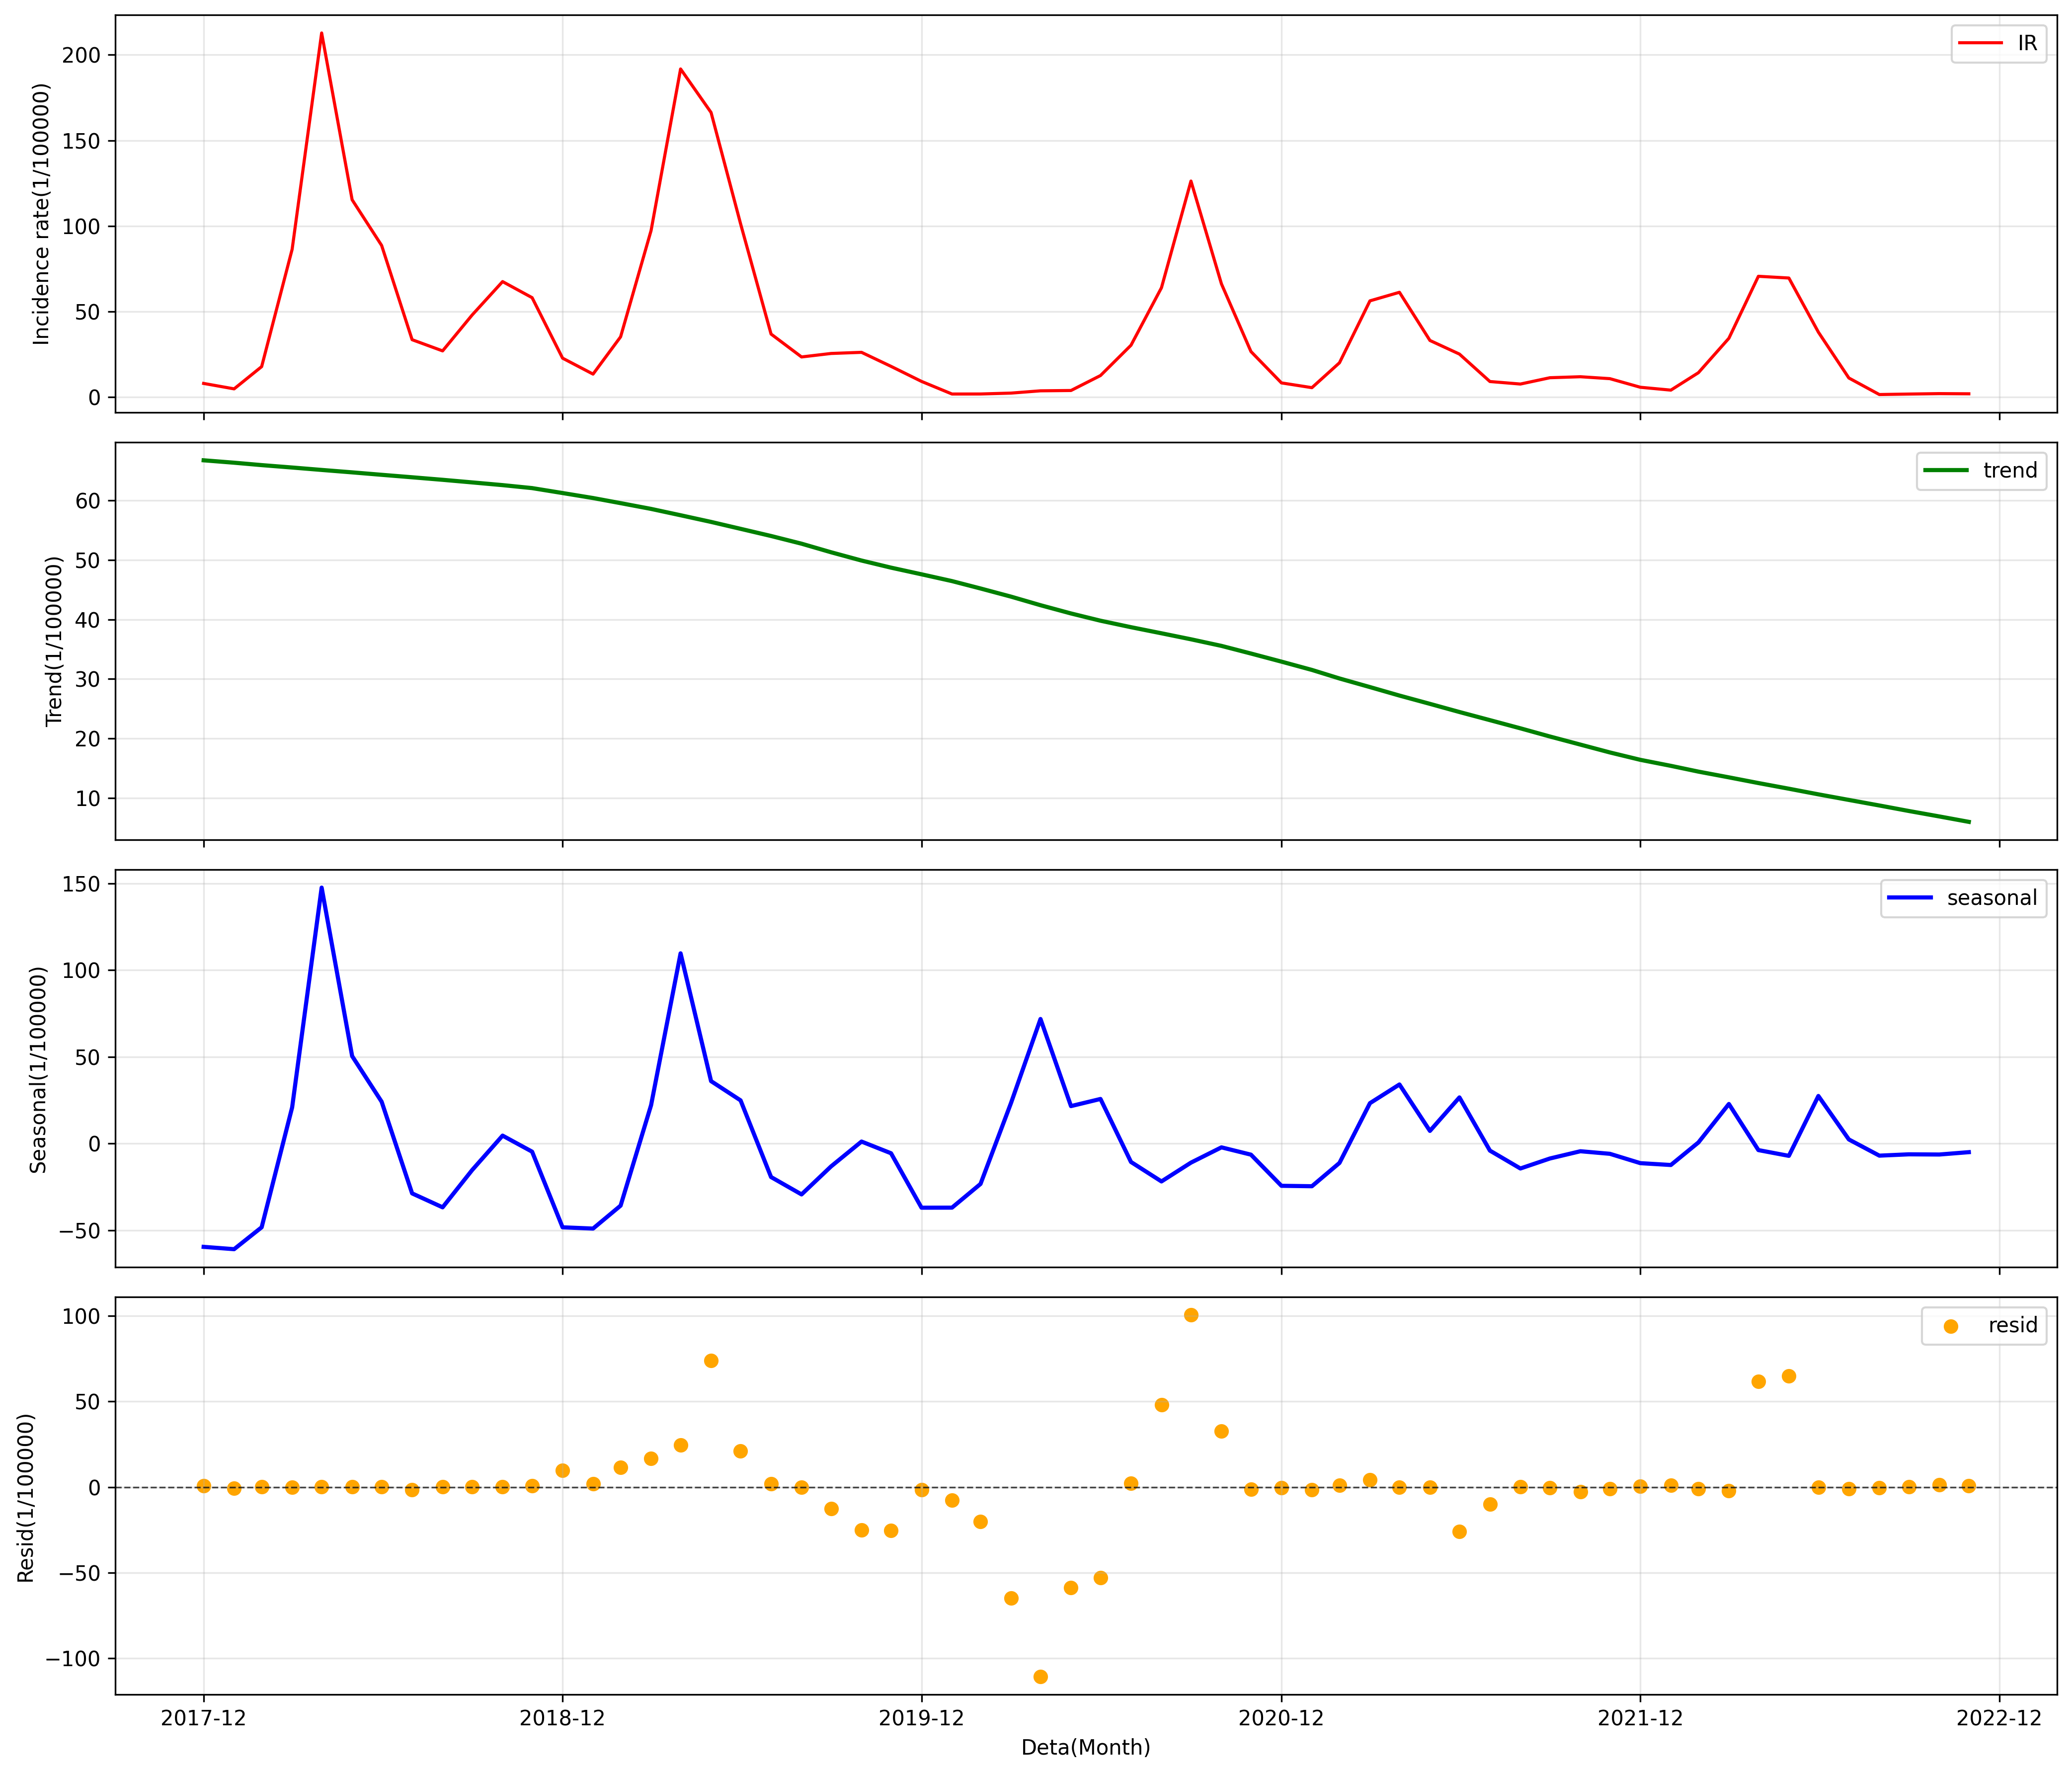

In [67]:
#绘制曲线图
import numpy as np
from matplotlib.dates import DateFormatter, AutoDateLocator
import matplotlib.pyplot as plt
fig,axes=plt.subplots(4, 1, figsize=(14, 12), sharex=True,dpi=300)
#原始HFMD数据
axes[0].plot(AnalysisData['Date'],AnalysisData['IR'], color="red", linewidth=1.5, label='IR')
axes[0].set_title("", fontsize=12)
axes[0].set_ylabel("Incidence rate(1/100000)")
axes[0].grid(alpha=0.3)
axes[0].legend()
#趋势成分
axes[1].plot(STLResult['Datetime'],STLResult['trend'], color="green", linewidth=2, label="trend")
axes[1].set_title("", fontsize=12)
axes[1].set_ylabel("Trend(1/100000)")
axes[1].grid(alpha=0.3)
axes[1].legend()
#季节成分
axes[2].plot(STLResult['Datetime'], STLResult['seasonal'], color="blue", linewidth=2, label="seasonal")
axes[2].set_title("", fontsize=12)
axes[2].set_ylabel("Seasonal(1/100000)")
axes[2].grid(alpha=0.3)
axes[2].legend()
#残差成分
axes[3].scatter(STLResult['Datetime'], STLResult['resid'], color="orange", linewidth=1, label="resid")
axes[3].axhline(y=0, color="black", linestyle="--", alpha=0.7, linewidth=0.8)
axes[3].set_title("", fontsize=12)
axes[3].set_xlabel('Deta(Month)')
axes[3].set_ylabel("Resid(1/100000)")
axes[3].grid(alpha=0.3)
axes[3].legend()
date_locator=AutoDateLocator()
date_formatter=DateFormatter("%Y-%m")
axes[3].xaxis.set_major_locator(date_locator)
axes[3].xaxis.set_major_formatter(date_formatter)
plt.tight_layout()
plt.show()

检验STL分解效果

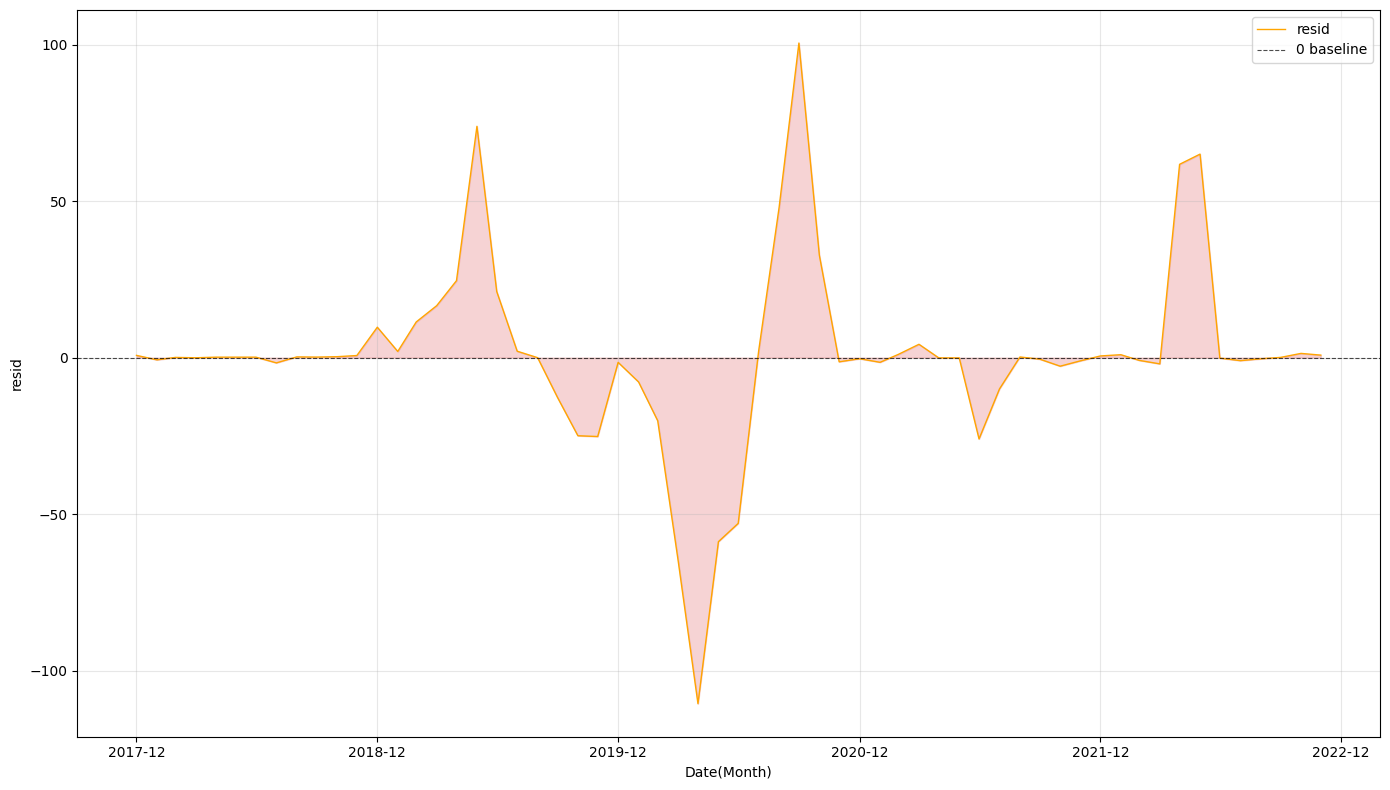

In [68]:
# 残差时间序列图
fig, axes = plt.subplots(1, 1, figsize=(14, 8), sharex=True)
axes.plot(STLResult['Datetime'],STLResult['resid'], color="orange", linewidth=1, label="resid")
axes.axhline(y=0, color="black", linestyle="--", alpha=0.7, linewidth=0.8, label='0 baseline')
axes.fill_between(STLResult['Datetime'], 0, resid, alpha=0.2, color="#d62728")
axes.set_title("", fontsize=12)
axes.set_ylabel("resid")
axes.set_xlabel("Date(Month)")
axes.grid(alpha=0.3)
axes.legend()
date_locator=AutoDateLocator()
date_formatter=DateFormatter("%Y-%m")
axes.xaxis.set_major_locator(date_locator)
axes.xaxis.set_major_formatter(date_formatter)
plt.tight_layout()
plt.show()

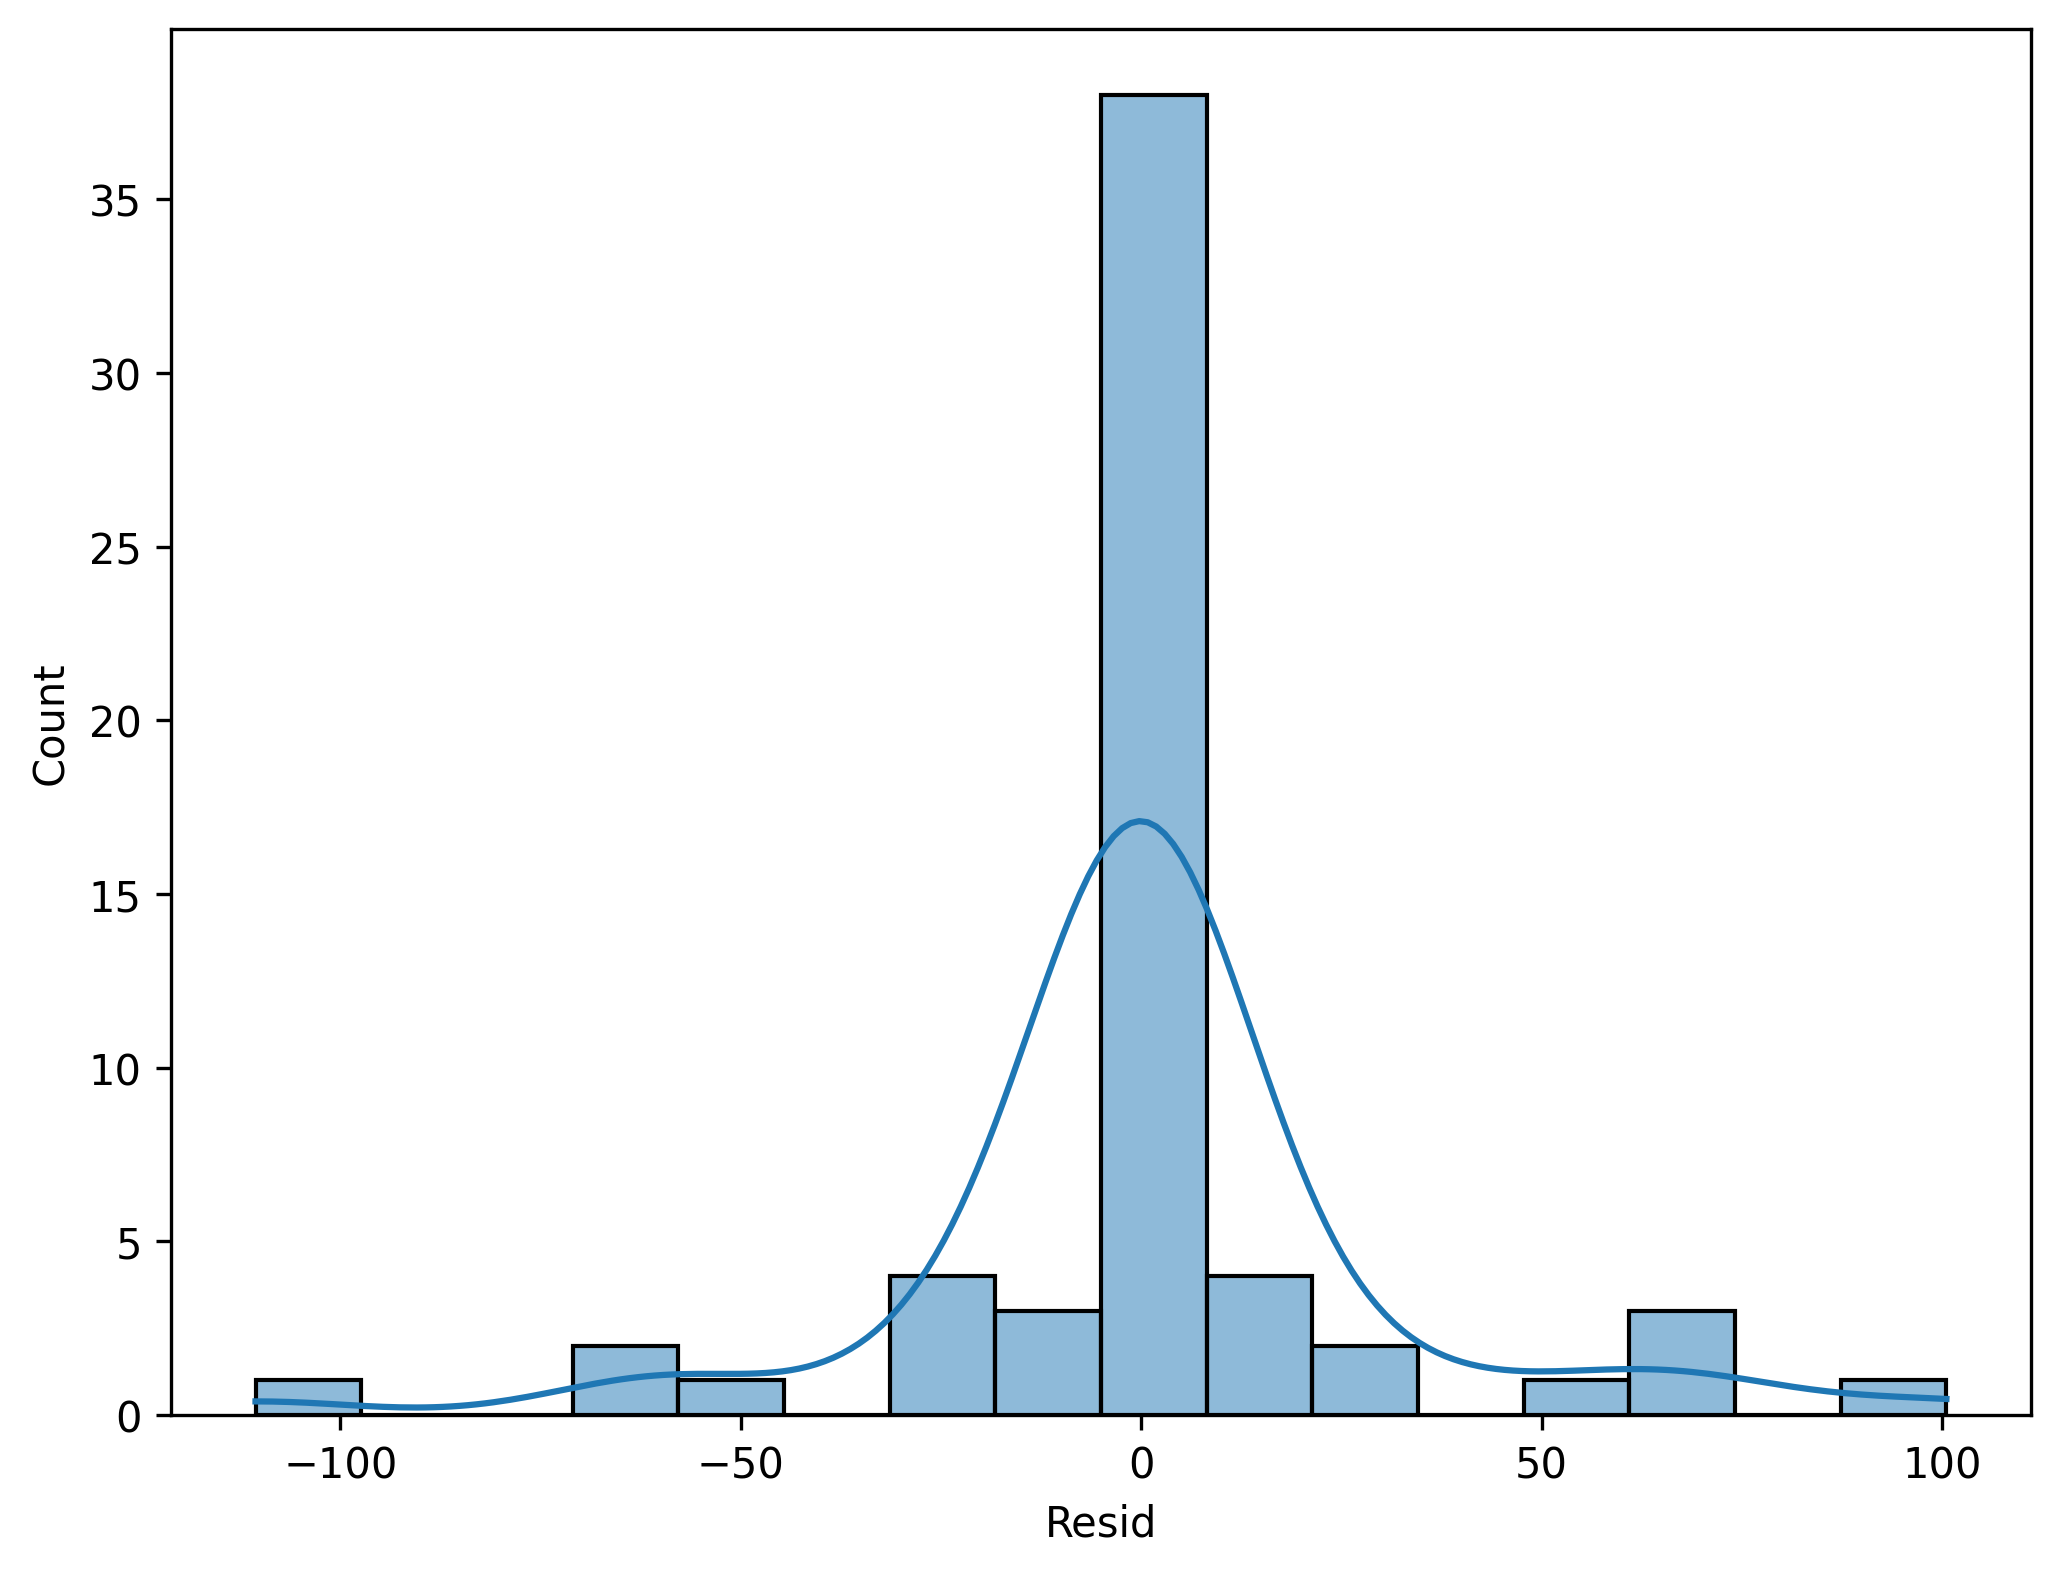

In [69]:
#绘制残差直方图
import seaborn as sns
from statsmodels.stats.diagnostic import acorr_ljungbox
#查看残差项分布
plt.figure(figsize=(8,6),dpi=300)
sns.histplot(STLResult['resid'],kde=True)
plt.xlabel('Resid')
plt.ylabel('Count')
plt.show()

In [70]:
#分析白噪声是否为正态分布
from scipy.stats import shapiro
stats,pvalue=shapiro(resid)
print(f'对白噪声的正态性检验结果统计量:{stats},P值为:{pvalue}')

对白噪声的正态性检验结果统计量:0.7759354401724893,P值为:3.559458425818115e-08


In [71]:
# 计算核心均值指标
seasonal_mean=seasonal.mean()
residual_mean=resid.mean()
print(f"季节性成分均值：{seasonal_mean:.4f}")
print(f"残差成分均值：{residual_mean:.4f}")
#计算残差项标准差合变异系数
residual_std=resid.std()
residual_cv=residual_std/abs(residual_mean) if abs(residual_mean) > 1e-6 else residual_std    #防止分母为0
print(f"残差标准差：{residual_std:.4f}")
print(f"残差变异系数：{residual_cv:.4f}")

季节性成分均值：-0.5239
残差成分均值：0.8920
残差标准差：30.2397
残差变异系数：33.8998


短期波动分析

In [72]:
#执行Ljung-Box检验，判断残差是否为纯随机噪声（白噪声）
from statsmodels.stats.diagnostic import acorr_ljungbox
resid_clean = resid.dropna()
lb_test = acorr_ljungbox(resid_clean, lags=24, return_df=True)
print(f'Ljung-Box检验(阶数20)结果:{lb_test}')

Ljung-Box检验(阶数20)结果:      lb_stat     lb_pvalue
1   27.322691  1.721790e-07
2   31.619139  1.361417e-07
3   31.652555  6.194440e-07
4   33.981019  7.518979e-07
5   37.685967  4.362923e-07
6   39.214573  6.496759e-07
7   39.267336  1.737839e-06
8   39.366542  4.202453e-06
9   41.088986  4.818813e-06
10  48.315397  5.435516e-07
11  57.199956  3.056739e-08
12  60.186490  2.087349e-08
13  61.266195  3.115590e-08
14  61.306088  6.914594e-08
15  62.430219  9.591704e-08
16  64.636279  8.507635e-08
17  65.485330  1.272167e-07
18  66.128731  2.018311e-07
19  69.875592  9.646632e-08
20  74.186083  3.721634e-08
21  75.122735  5.186367e-08
22  75.263726  9.581950e-08
23  76.757632  1.054892e-07
24  80.879934  4.402955e-08


In [73]:
significant_lags=lb_test[lb_test["lb_pvalue"] < 0.05].index.tolist()
print("Ljung-Box检验判别结果：")
if len(significant_lags) == 0:
    print("所有滞后阶数的p值均>0.05，残差为纯随机噪声，无真实短期波动。")
else:
    print(f"存在{len(significant_lags)}个滞后阶数p值<0.05，残差非纯随机噪声，包含真实短期波动。")
    print(f"显著滞后阶数：{significant_lags}")

Ljung-Box检验判别结果：
存在24个滞后阶数p值<0.05，残差非纯随机噪声，包含真实短期波动。
显著滞后阶数：[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]


In [74]:
#输出Ljung-Box检验结果
lb_test.to_csv('/root/ToResult/Stage1DescriptiveAnalysis/LjungBoxResult.csv',encoding='utf-8')

季节性分析

In [75]:
# 计算季节成分的标准差
seasonal_std=np.std(seasonal.dropna())
seasonal_max=np.max(seasonal.dropna())
seasonal_min=np.min(seasonal.dropna())
seasonal_range=seasonal_max - seasonal_min
# 输出结果
print(f"季节成分标准差：{seasonal_std:.4f}")
print(f"季节成分最大值：{seasonal_max:.4f}")
print(f"季节成分最小值：{seasonal_min:.4f}")
print(f"季节成分极差：{seasonal_range:.4f}")
print(f"标准差{seasonal_std:.4f}越大，说明HFMD发病率的季节性波动越剧烈。")

季节成分标准差：35.5883
季节成分最大值：147.5414
季节成分最小值：-60.8743
季节成分极差：208.4157
标准差35.5883越大，说明HFMD发病率的季节性波动越剧烈。


基于加法STL分解模型计算季节指数
1.通过STL分解获取完整季节性成分.
2.将季节性成分S(t)按季节周期P进行分组，把所有相同季节节点k的S(t)归集为一组，得到P个分组集合.
3.计算每组均值作为初始季节指数(SI).
4.计算初始季节指数的周期均值，每个初始季节指数减去该均值，得到修正后的最终季节指数。

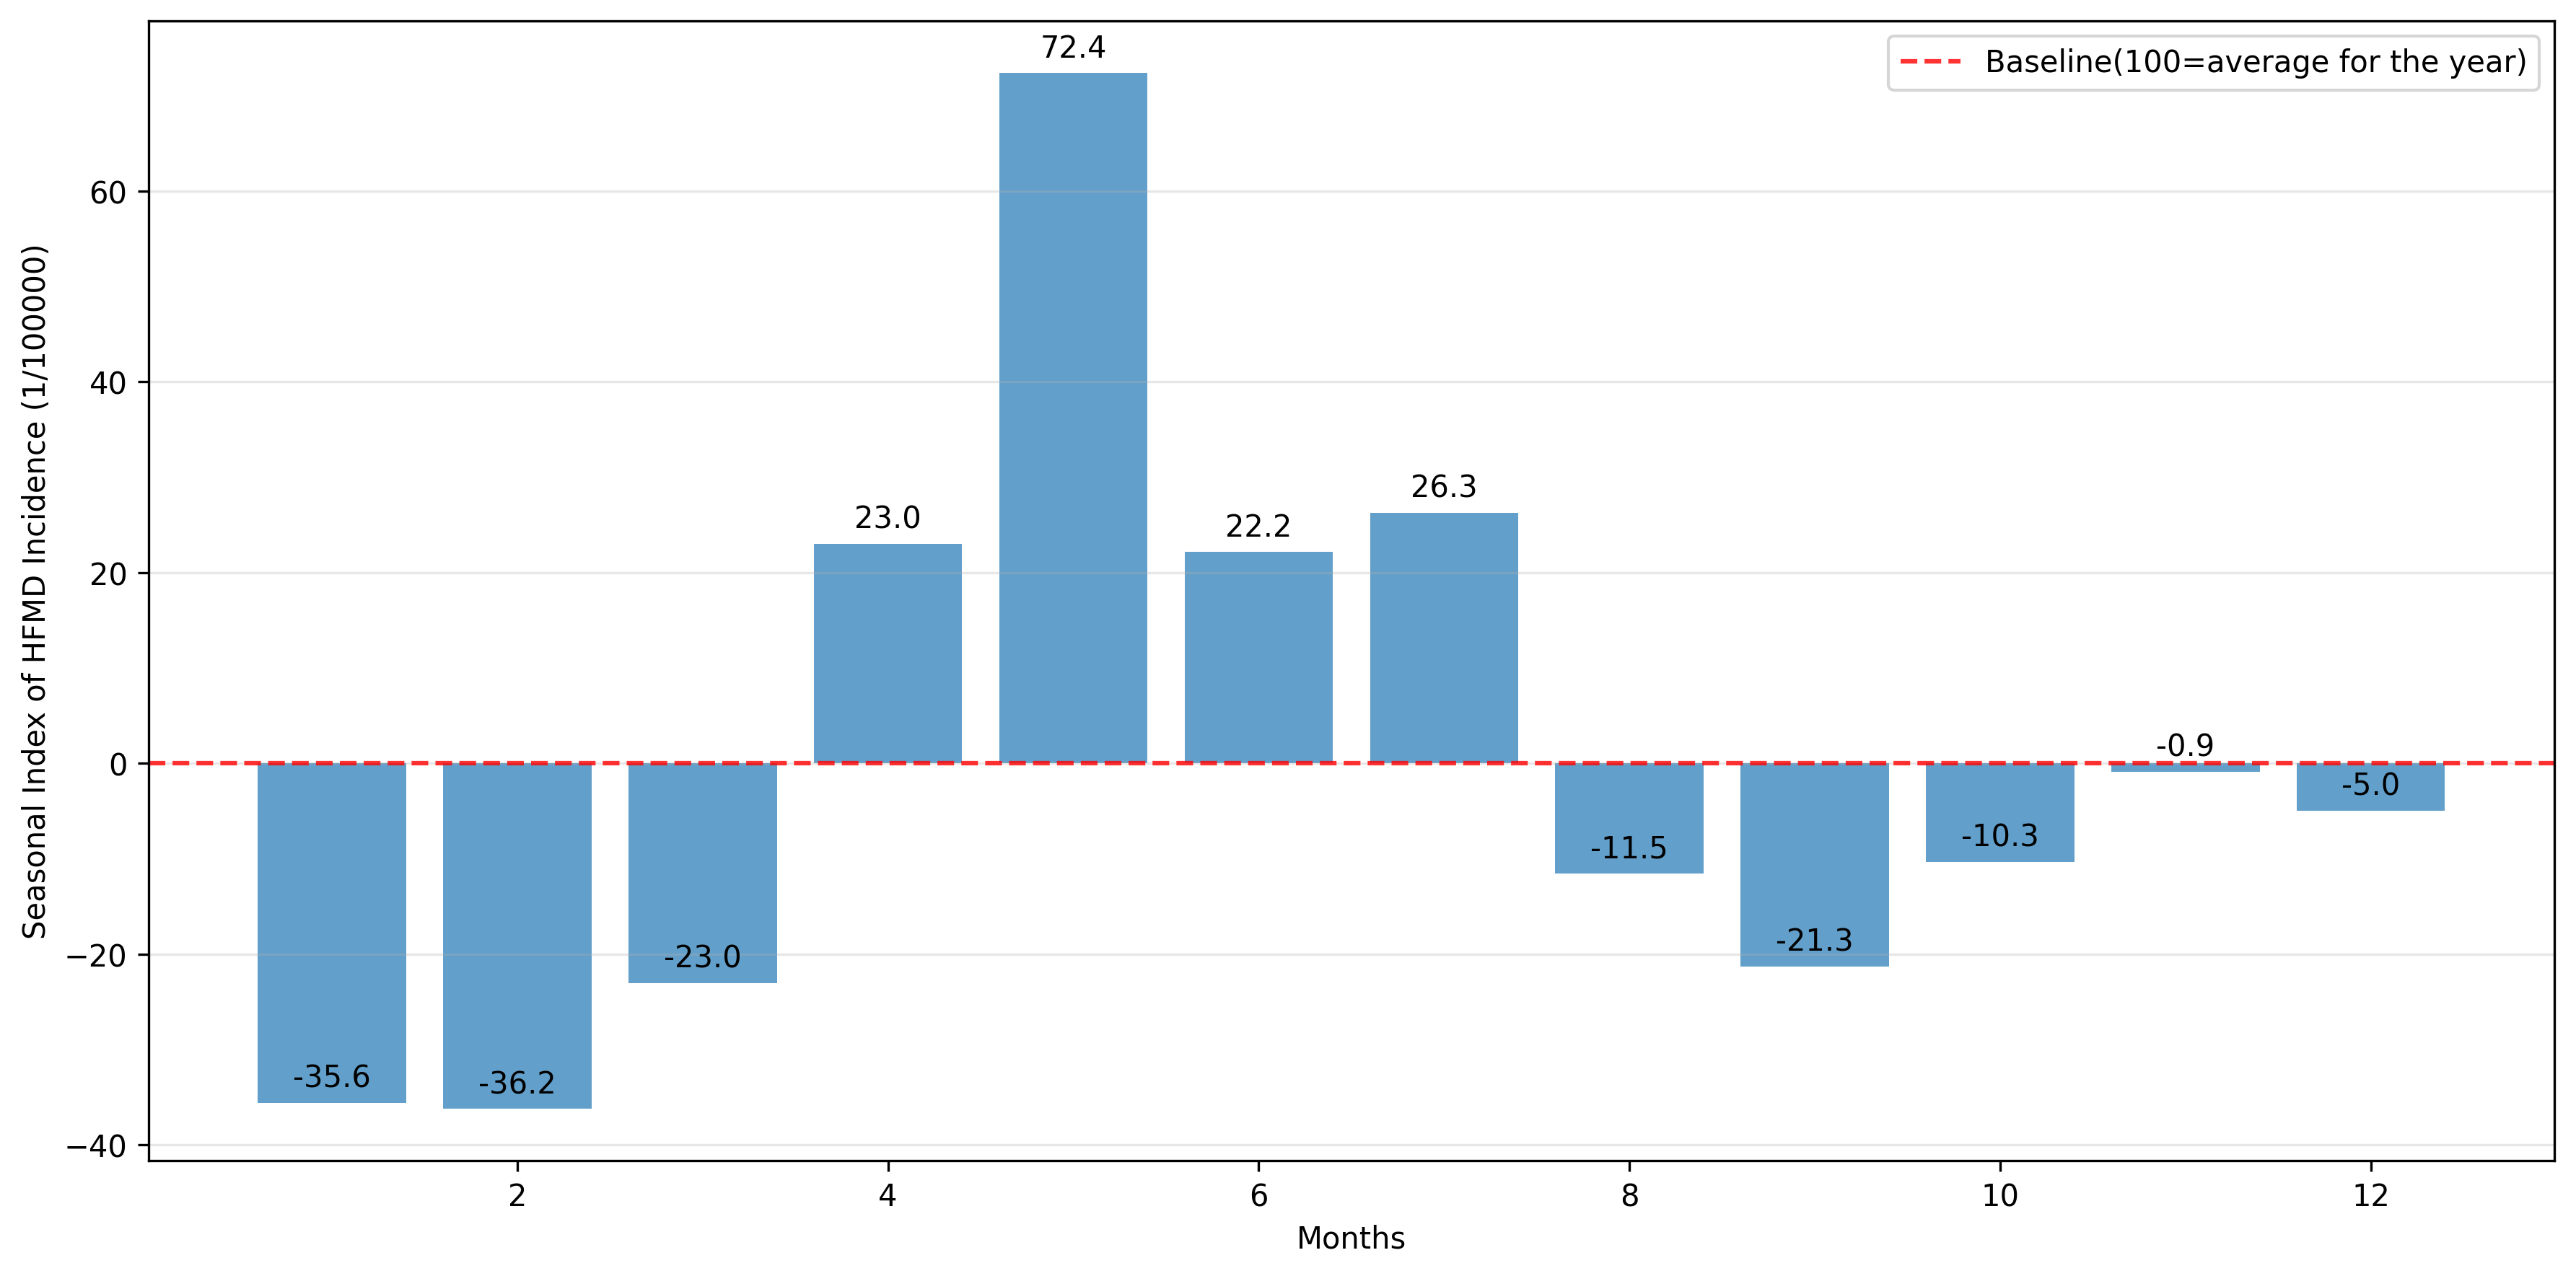

In [76]:
#计算季节指数
seasonal_df=seasonal.reset_index()
seasonal_df.rename(columns={'index': 'date', 0: 'seasonal_value'}, inplace=True)
seasonal_df['season_node']=seasonal_df['Date'].dt.month    #提取月份数据
initial_seasonal_index=seasonal_df.groupby('season_node')['season'].mean()    #以月份为分组依据，计算各组均值(原始SI)
#归一化SI
initial_si_df=initial_seasonal_index.reset_index()   
initial_si_df.rename(columns={'season':'initial_si'}, inplace=True)
cycle_mean=initial_si_df['initial_si'].mean()    
initial_si_df['si']=initial_si_df['initial_si']-cycle_mean    #归一化原始SI
final_seasonal_index=initial_si_df.set_index('season_node')['si']
#可视化季节指数
plt.figure(figsize=(12, 6),dpi=300)
bars=plt.bar(initial_si_df["season_node"],initial_si_df["si"], color="#1f77b4", alpha=0.7)
plt.axhline(y=0, color="red", linestyle="--", alpha=0.8, label="Baseline(100=average for the year)")
plt.title("", fontsize=14)
plt.xlabel("Months")
plt.ylabel("Seasonal Index of HFMD Incidence (1/100000)")
plt.grid(alpha=0.3, axis="y")
plt.legend()
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1,
             f"{height:.1f}", ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.show()

In [77]:
#导出季节指数
initial_si_df.to_csv('/root/ToResult/Stage1DescriptiveAnalysis/HFMDSI.csv',encoding='utf-8')

长期趋势分析

In [78]:
#对趋势项拟合非线性模型
from scipy.optimize import curve_fit
trend_clean=trend.dropna()
t=np.arange(len(trend_clean))    #将datetime转换为连续整数方便拟合
trend_values = trend_clean.values
#定义非线性模型
def quadratic_model(t,a,b,c):
    return a*(t**2)+b*t+c
#拟合多项式
popt,pcov=curve_fit(quadratic_model, t, trend_values)
a,b,c=popt
#生成拟合趋势值
trend_fit=quadratic_model(t, a, b, c)
#计算趋势斜率,采用一阶导数(dy/dt=2*a*t+b)反映趋势变化速率
trend_slope=2*a*t+b
#计算平均斜率、初始斜率、末端斜率
avg_slope=np.mean(trend_slope)
init_slope=trend_slope[0]
end_slope=trend_slope[-1]

In [79]:
#导数结果
trend_slope

array([-0.81655156, -0.82738964, -0.83822771, -0.84906579, -0.85990386,
       -0.87074194, -0.88158002, -0.89241809, -0.90325617, -0.91409424,
       -0.92493232, -0.93577039, -0.94660847, -0.95744654, -0.96828462,
       -0.97912269, -0.98996077, -1.00079885, -1.01163692, -1.022475  ,
       -1.03331307, -1.04415115, -1.05498922, -1.0658273 , -1.07666537,
       -1.08750345, -1.09834152, -1.1091796 , -1.12001768, -1.13085575,
       -1.14169383, -1.1525319 , -1.16336998, -1.17420805, -1.18504613,
       -1.1958842 , -1.20672228, -1.21756035, -1.22839843, -1.2392365 ,
       -1.25007458, -1.26091266, -1.27175073, -1.28258881, -1.29342688,
       -1.30426496, -1.31510303, -1.32594111, -1.33677918, -1.34761726,
       -1.35845533, -1.36929341, -1.38013149, -1.39096956, -1.40180764,
       -1.41264571, -1.42348379, -1.43432186, -1.44515994, -1.45599801])

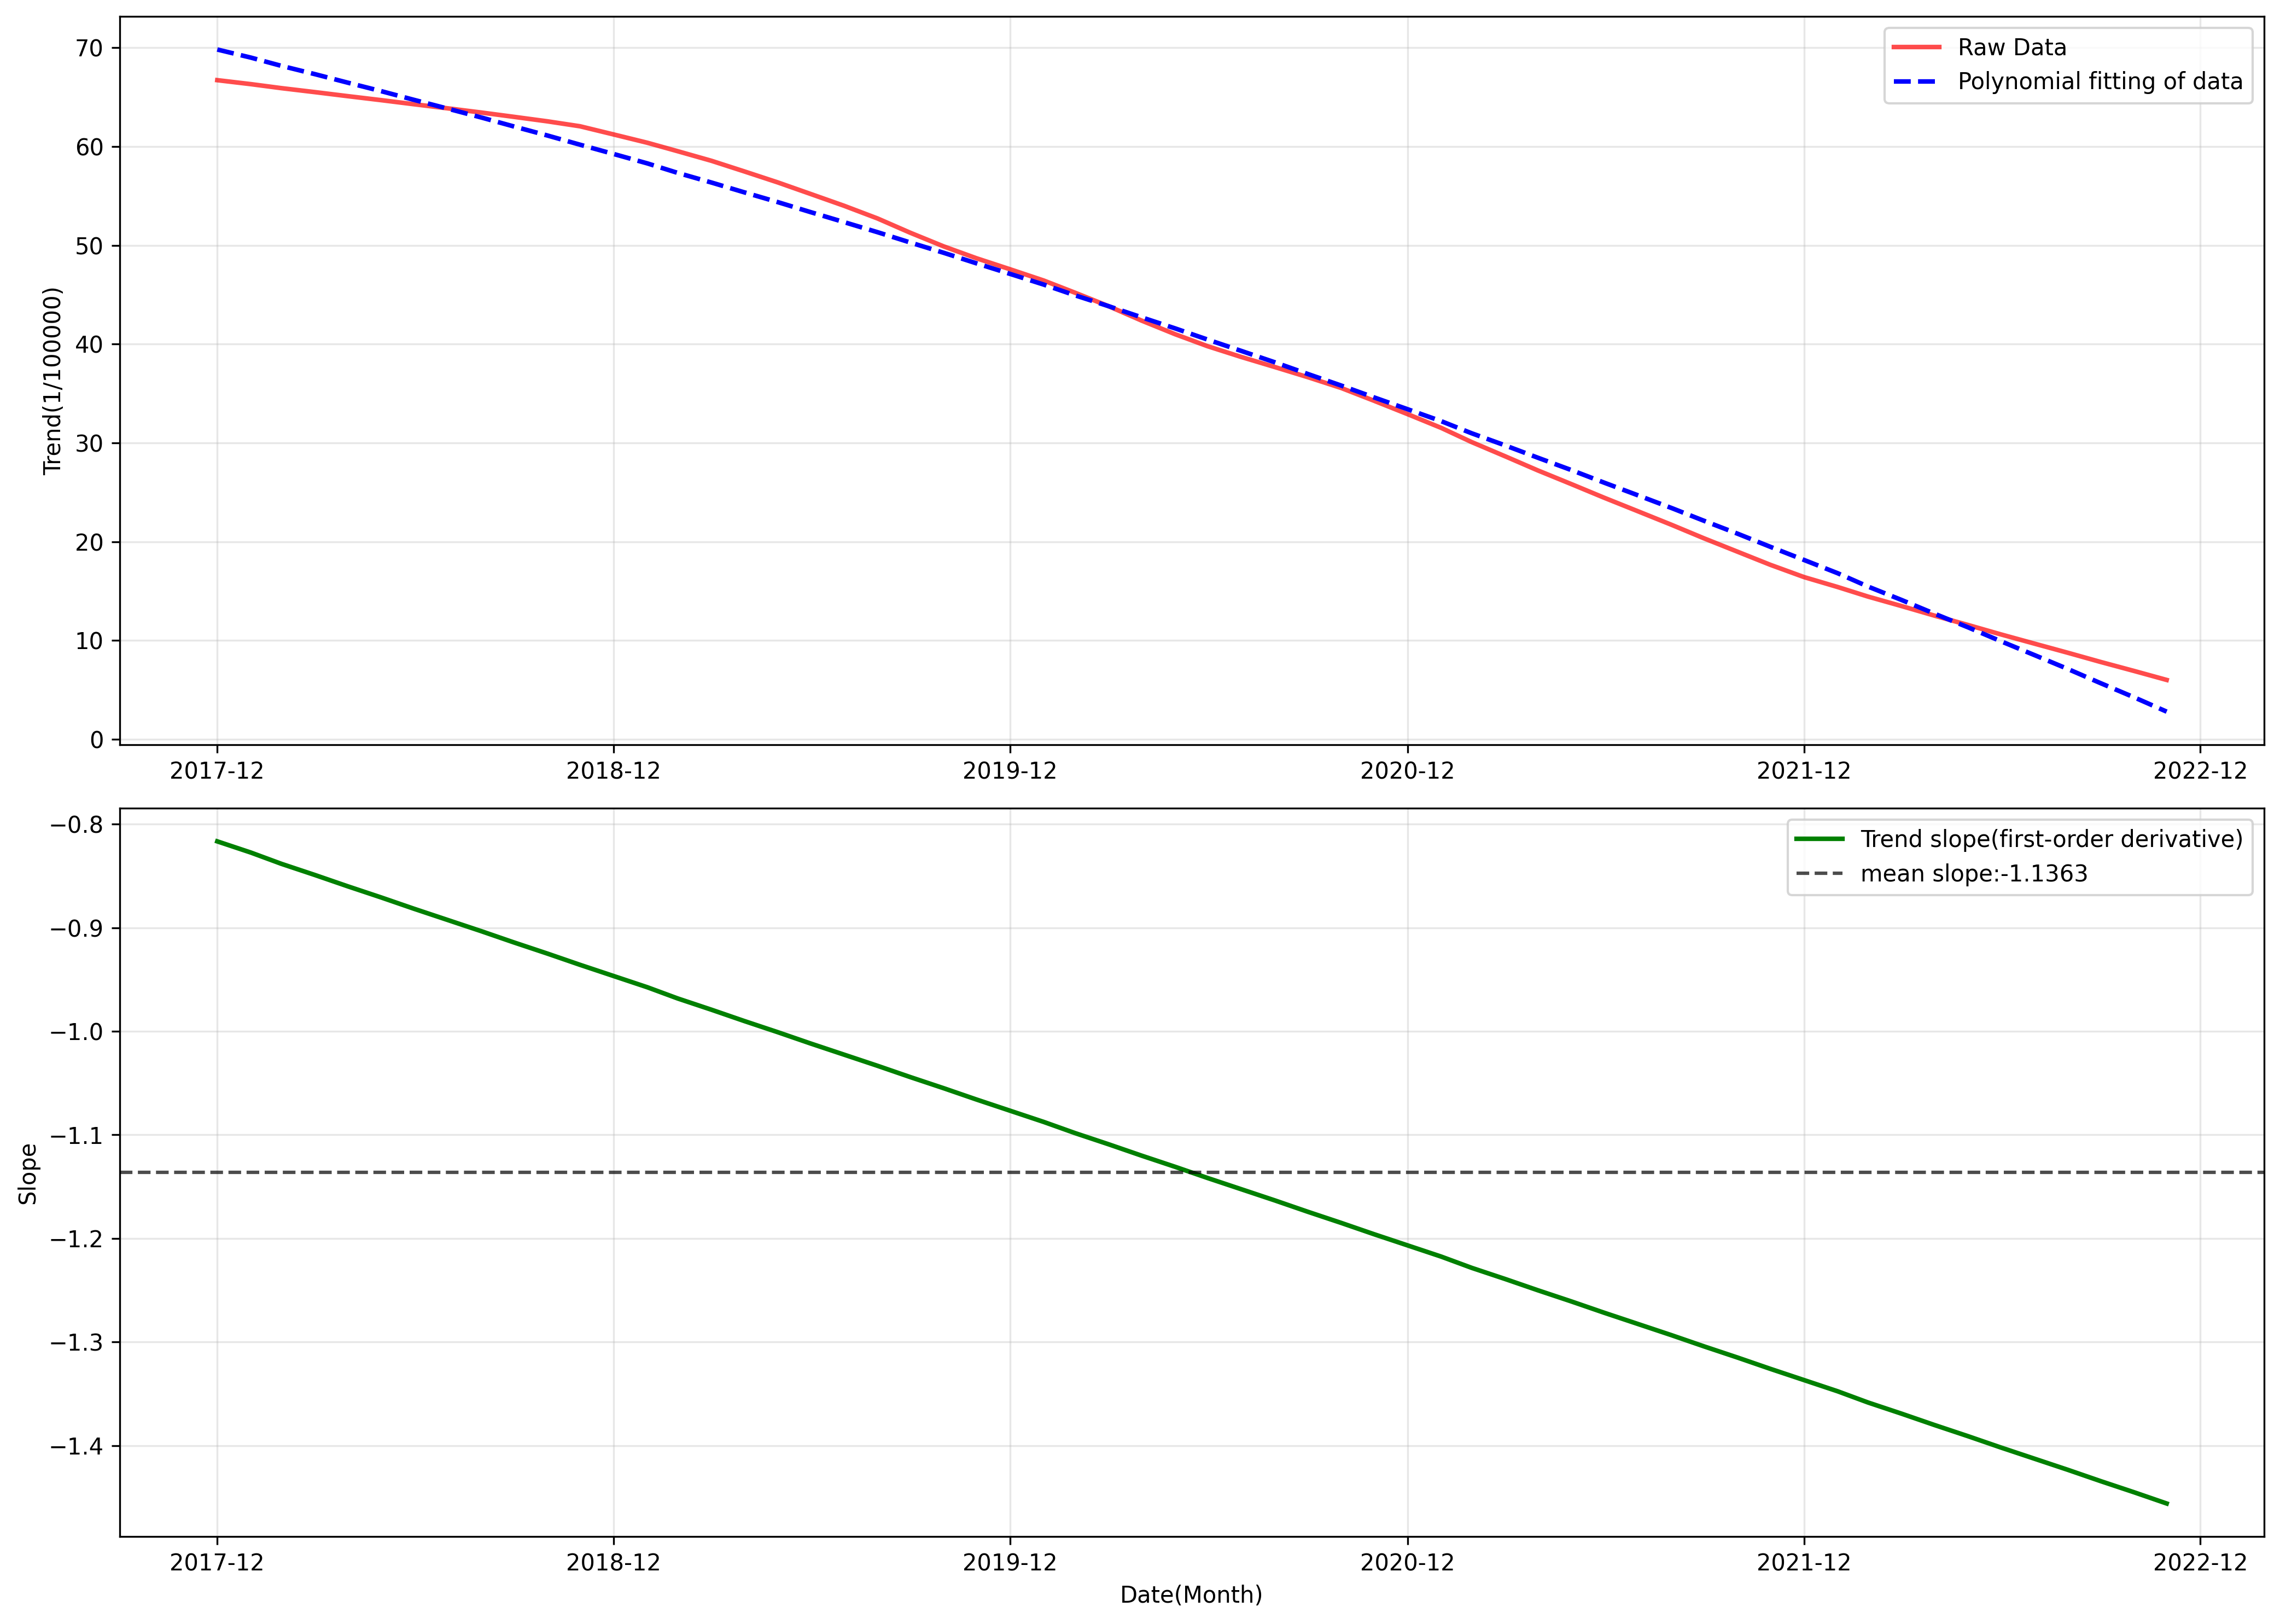

In [80]:
#绘制趋势成分与拟合模型对比图
fig, axes = plt.subplots(2, 1, figsize=(14, 10),dpi=300)
# 趋势成分与拟合模型
axes[0].plot(trend_clean.index, trend_values, color="red", linewidth=2, label="Raw Data", alpha=0.7)
axes[0].plot(trend_clean.index, trend_fit, color="blue", linewidth=2, linestyle="--", label='Polynomial fitting of data')
axes[0].set_title("", fontsize=12)
axes[0].set_ylabel("Trend(1/100000)")
axes[0].grid(alpha=0.3)
axes[0].legend()
date_locator_d=AutoDateLocator()
date_formatter_d=DateFormatter("%Y-%m")
axes[0].xaxis.set_major_locator(date_locator_d)
axes[0].xaxis.set_major_formatter(date_formatter_d)
# 趋势斜率变化曲线
axes[1].plot(trend_clean.index, trend_slope, color="green", linewidth=2, label="Trend slope(first-order derivative)")
axes[1].axhline(y=avg_slope, color="black", linestyle="--", alpha=0.7, label=f"mean slope:{avg_slope:.4f}")
axes[1].set_title("", fontsize=12)
axes[1].set_xlabel("Date(Month)")
axes[1].set_ylabel('Slope')
axes[1].grid(alpha=0.3)
axes[1].legend()
date_locator_d=AutoDateLocator()
date_formatter_d=DateFormatter("%Y-%m")
axes[1].xaxis.set_major_locator(date_locator_d)
axes[1].xaxis.set_major_formatter(date_formatter_d)
plt.tight_layout()
plt.show()

In [81]:
#采用MAE、MSE和R2评价模型拟合效果
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
mse=mean_squared_error(trend_values,trend_fit)
mae=mean_absolute_error(trend_values,trend_fit)
r2=r2_score(trend_values,trend_fit)
print(f'非线性模型拟合结果MSE:{mse},MAE:{mae},R2:{r2}')

非线性模型拟合结果MSE:2.1716896211770385,MAE:1.2431765915024227,R2:0.9944530648295706


In [82]:
# 7. 输出趋势拟合与斜率结果
print("非线性趋势拟合结果:")
print(f"模型参数:a={a:.6f}, b={b:.4f}, c={c:.4f}")
print(f"模型公式:y = {a:.6f}*t² + {b:.4f}*t + {c:.4f}")
print(f"初始斜率（t=0）：{init_slope:.4f}")
print(f"末端斜率（t={len(t)-1}）：{end_slope:.4f}")
print(f"平均斜率：{avg_slope:.4f}")
print(f"斜率从{init_slope:.4f}变化至{end_slope:.4f}，{'上升' if end_slope > init_slope else '下降'}了{abs(end_slope - init_slope):.4f}，说明HFMD发病率趋势{'加速上升' if a>0 else '减速变化'}。")

非线性趋势拟合结果:
模型参数:a=-0.005419, b=-0.8166, c=69.8273
模型公式:y = -0.005419*t² + -0.8166*t + 69.8273
初始斜率（t=0）：-0.8166
末端斜率（t=59）：-1.4560
平均斜率：-1.1363
斜率从-0.8166变化至-1.4560，下降了0.6394，说明HFMD发病率趋势减速变化。


In [83]:
from scipy.stats import linregress
import pymannkendall as mk
def trend_analysis(derivative: np.ndarray):
    #Mann-Kendall检验
    mk_result = mk.original_test(derivative)  
    mk_z = mk_result.z 
    mk_p = mk_result.p 
    mk_trend = mk_result.trend  
    # 线性回归斜率检验
    reg = linregress(np.arange(len(derivative)), derivative)
    slope = reg.slope
    reg_p = reg.pvalue
    # 趋势判断
    def get_trend(s, p, alpha=0.05):
        if p < alpha:
            return "显著上升" if s > 0 else "显著下降"
        return "无显著趋势"
    reg_trend = get_trend(slope, reg_p)

    return {
        "MK统计量Z": round(mk_z, 4),
        "MK检验p值": round(mk_p, 4),
        "MK趋势结论": mk_trend,
        "回归斜率": round(slope, 4),
        "回归检验p值": round(reg_p, 4),
        "回归趋势结论": reg_trend
    }
# 执行检验
result = trend_analysis(trend_slope)
result

{'MK统计量Z': np.float64(-11.2826),
 'MK检验p值': np.float64(0.0),
 'MK趋势结论': 'decreasing',
 '回归斜率': np.float64(-0.0108),
 '回归检验p值': np.float64(0.0),
 '回归趋势结论': '显著下降'}

周期性分析

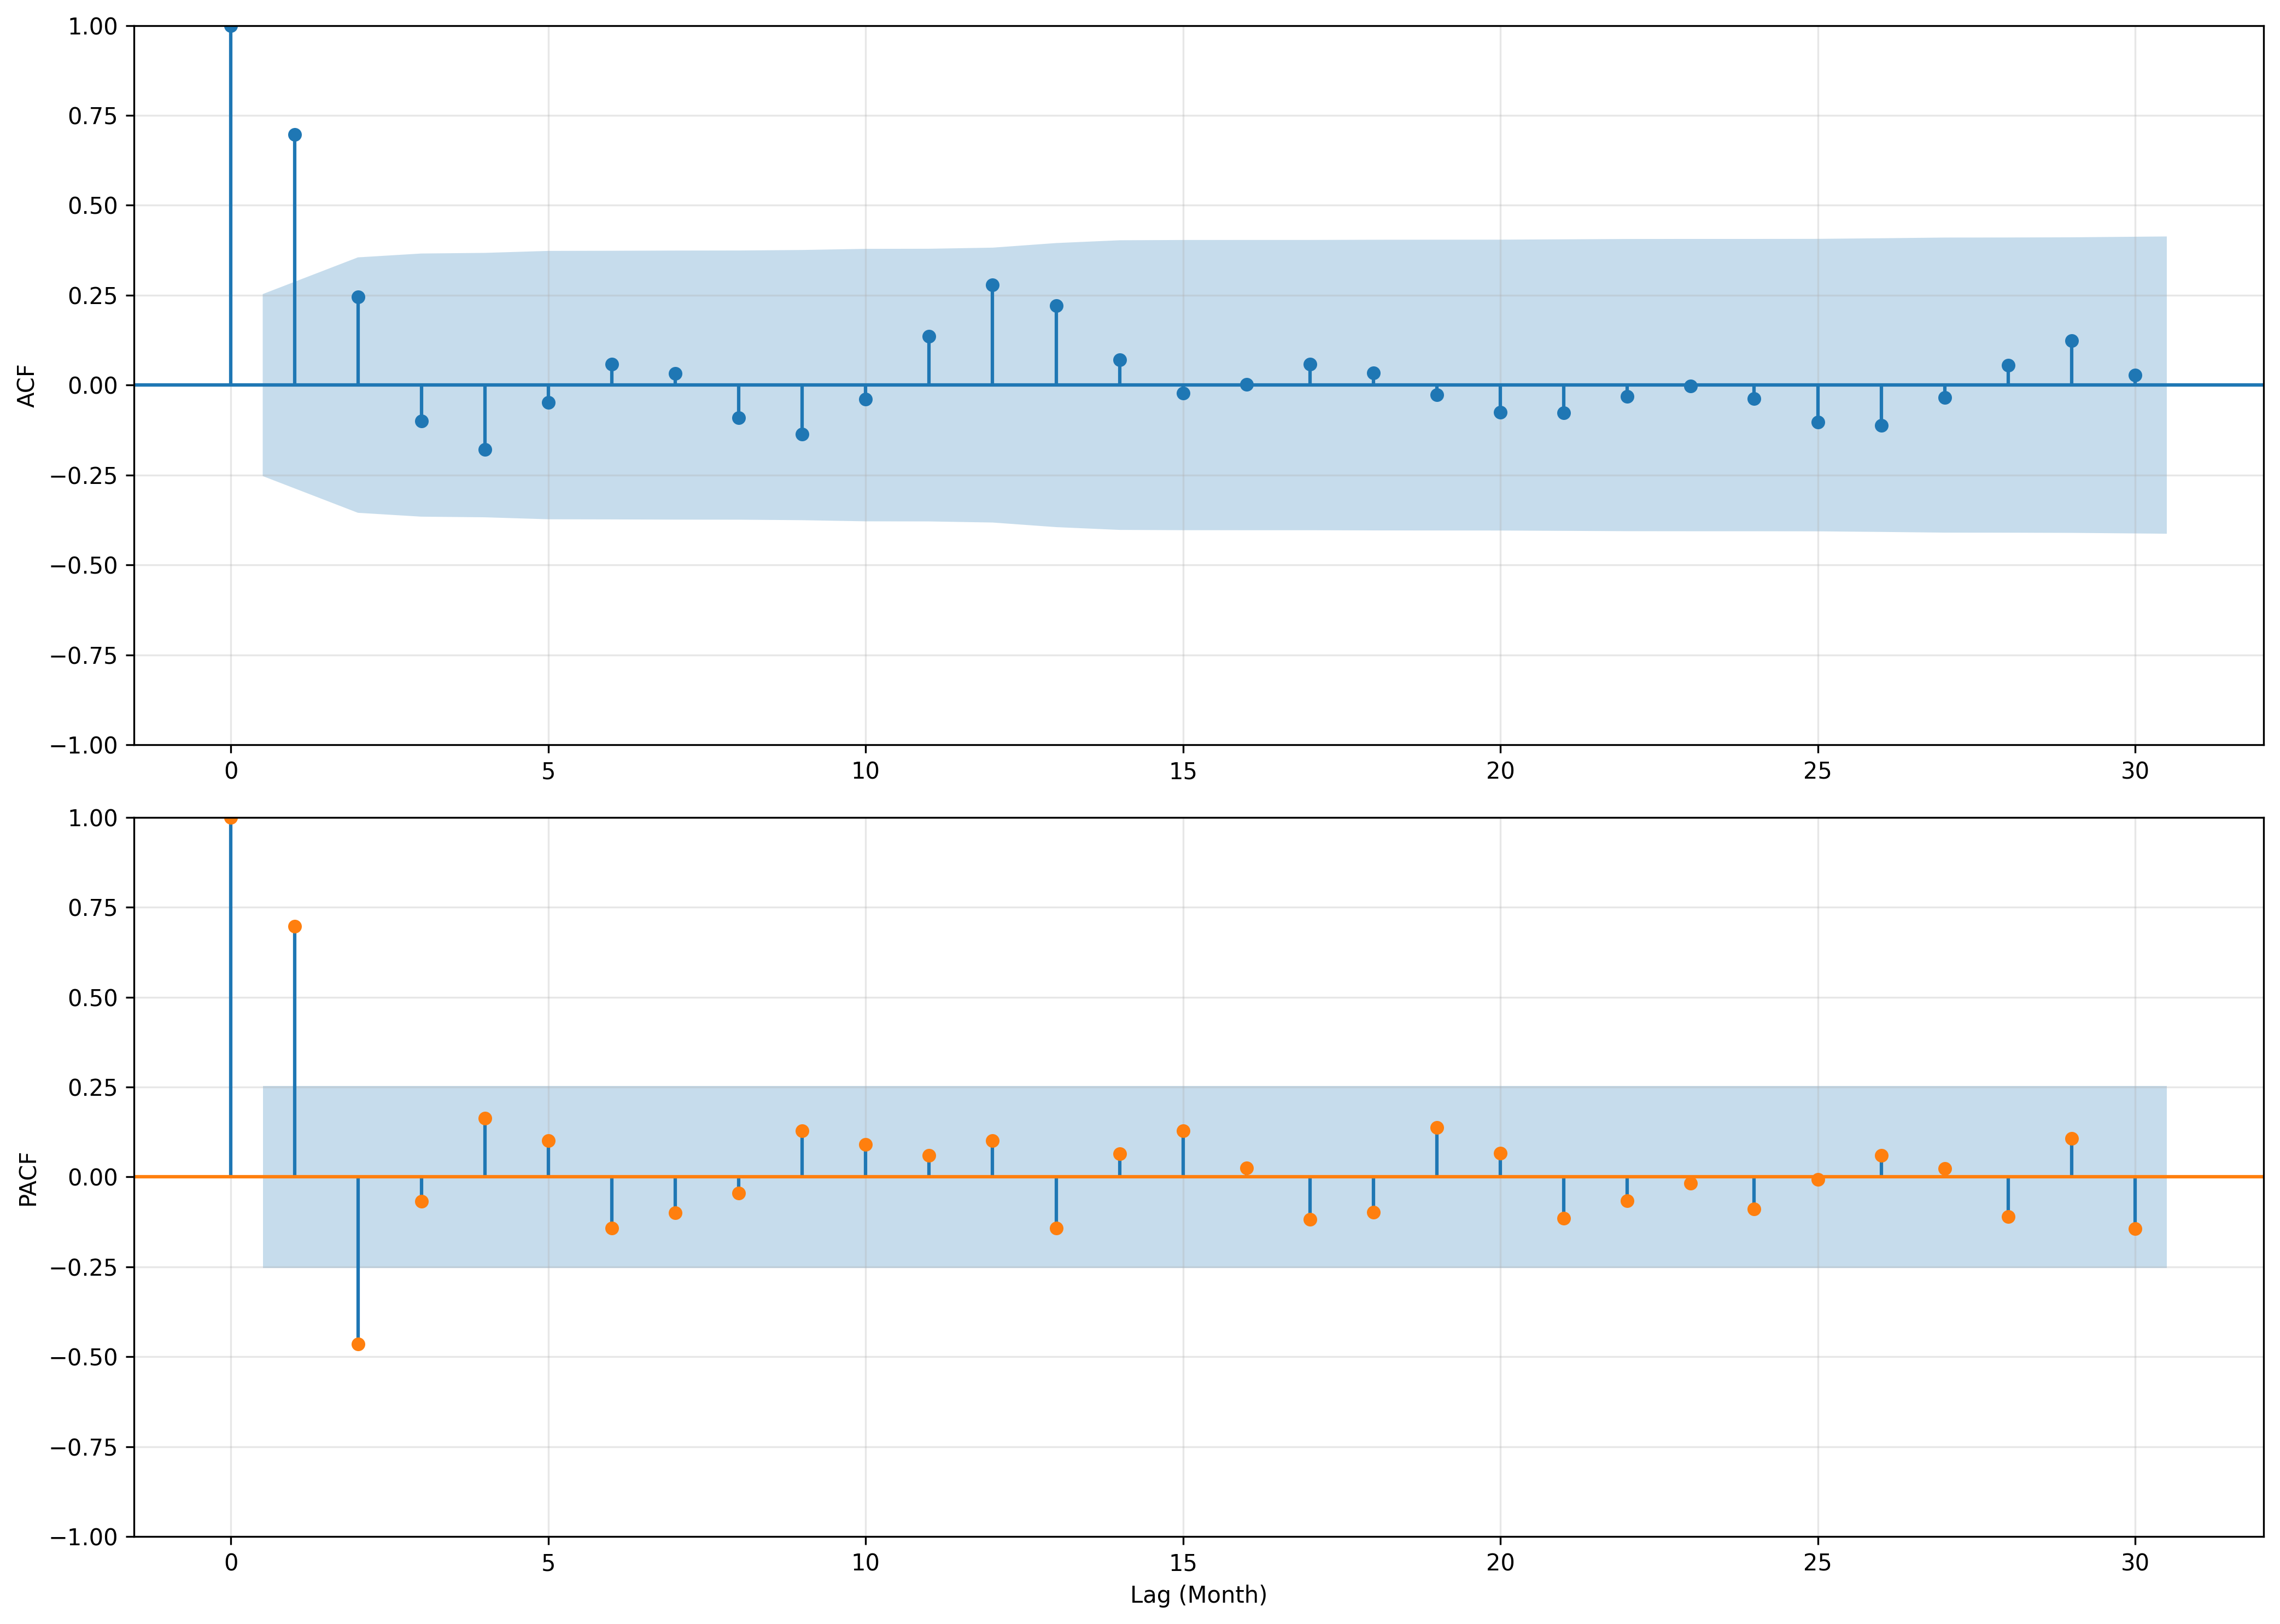

In [84]:
#计算和绘制ACF以及PACF图
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
hfmd_clean=AnalysisData["IR"].dropna()
fig, axes = plt.subplots(2, 1, figsize=(14, 10),dpi=300)
#绘制ACF图
plot_acf(hfmd_clean, lags=30, ax=axes[0], alpha=0.05, color="#1f77b4")
axes[0].set_title("", fontsize=12)
axes[0].set_ylabel('ACF')
axes[0].grid(alpha=0.3)
#绘制PACF图
plot_pacf(hfmd_clean, lags=30, ax=axes[1], alpha=0.05, color="#ff7f0e")
axes[1].set_title("", fontsize=12)
axes[1].grid(alpha=0.3)
axes[1].set_xlabel('Lag (Month)')
axes[1].set_ylabel('PACF')
plt.tight_layout()
plt.show()

ACF：1阶截尾；
PACF：呈现1阶截尾特征；
HFMD发病率数据的周期为12个月（年度周期）

In [85]:
# 输出ACF核心信息
from statsmodels.tsa.stattools import acf, pacf
acf_values=acf(hfmd_clean,nlags=30,alpha=0.05,fft=False)
pacf_values=pacf(hfmd_clean, nlags=30,alpha=0.05)

In [86]:
#汇总和输出ACF以及PACF值
ACF=DataFrame(acf_values).T
ACF.columns=['ACF','95%CI']
PACF=DataFrame(pacf_values).T
PACF.columns=['PACF','95%CI']

In [87]:
#输出ACF和PACF值
ACF.to_csv('/root/ToResult/Stage1DescriptiveAnalysis/ACFResult.csv',encoding='utf-8')
PACF.to_csv('/root/ToResult/Stage1DescriptiveAnalysis/PACFResult.csv',encoding='utf-8')